# Replicate QST article sims

### 1. RSB Hamiltonian Figure 1b

In the Fock mixtures paper, Figure 1b shows the dynamics under the RSB Hamiltonian with dissipation. The full ion trap QHO hamiltonian is:
$$
H = \frac{\Delta}{2}\sigma_{z} + \nu aa^{\dagger} + \frac{\Omega}{2}\big[\sigma^{+}D(i\eta) +\sigma^{-}D^{\dagger}(i\eta) \big]
$$

Where $D(i\eta) = e^{i\eta(a + a^{\dagger})}$ is the displacement operator. In the Lamb-Dicke regime, we can approximate this Hamiltonian to the first red sideband (RSB) interaction:
$$
H' = \frac{i\Omega\eta}{2}\big[\sigma_x(a^{\dagger} + a )\big]
$$


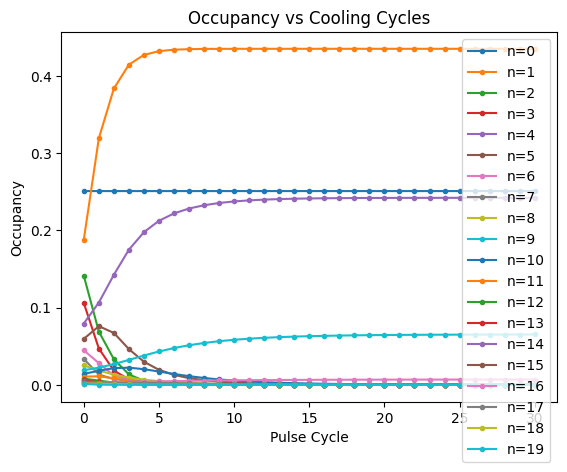

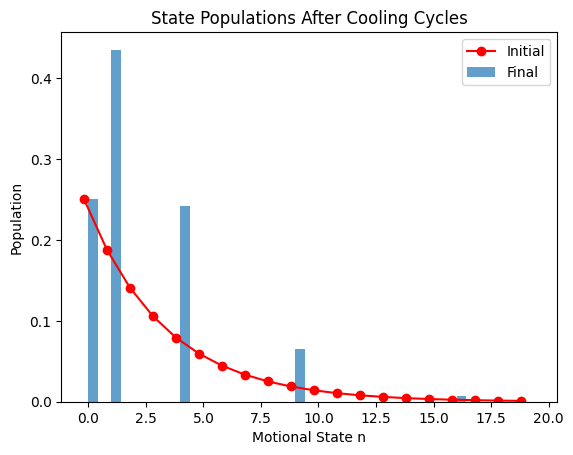

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 1.0  # Detuning
nu = 1.0     # Motional frequency
Omega=.02  # Rabi frequency
eta = 0.02    # Lamb-Dicke parameter
n_thermal = 3  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
beta = 0.01    # Inverse temperature
kT = 1.0      # Boltzmann constant times temperature
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration

# Define operators
N = 20  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))

# Hamiltonian (Red Sideband for Pulse)
# H_pulse = 1j*eta*Omega/2 * (a_full* s_plus_full - a_dag_full * s_minus_full)
# Displacement operator D(i*eta)
# Note: In the paper, the argument is i*eta.
D_op = tensor(qeye(2), displace(N, 1j * eta))

# RSB Hamiltonian (Figure 1b)
H_pulse = -1j*eta*Omega/2 * (a_full* s_plus_full - a_dag_full * s_minus_full)

# Hamiltonian (Free evolution for Dissipation) - Assuming H0 during dissipation phase? 
# For now, let's assume H_diss = 0 for the dissipative step relative to the rotating frame.
H_diss = Delta*s_z_full/2 + nu*a_dag_full*a_full

# --- Collapse Operators for Dissipation with recoil ---
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2  # This is Γ/2 in the master equation
tg = 2 / G  # Dissipation duration adjusted for rates
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# Add sigma_minus decay without recoil (optional, for comparison)
c_ops.append(np.sqrt(gamma) * s_minus_full)

# --- Construct Liouvillians ---
# 1. Pulse Step: Coherent RSB drive, NO dissipation (or minimal?)
# Typically only Unitary part active during pulse
L_pulse = liouvillian(H_pulse, []) 

# 2. Dissipation Step: No Drive, ONLY Dissipation (Optical Pumping)
# H = 0 (or H0), c_ops active
L_diss = liouvillian(H_diss, c_ops)

# --- Propagators ---
# Propagator for Pulse step (duration tau)
prop_pulse = (L_pulse * tau).expm()

# Propagator for Dissipation step (duration tg)
prop_diss = (L_diss * tg).expm()

# Combined Propagator for one cycle (Pulse -> Dissipation)
prop_cycle = prop_diss * prop_pulse 


# --- Simulation ---
num_pulses = 30 # Number of cycles
times_sim = np.arange(num_pulses + 1) # Just integer steps for cycles

# Initial state
rho_thermal = thermal_dm(N, n_thermal)
p_thermal = rho_thermal.diag()
ground_state = basis(2, 1) 
initial_state = tensor(ground_state * ground_state.dag(), rho_thermal)

# Storage
occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)

# Initial occupancy
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

# Evolve step-by-step
current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec
    
    # Store
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real


# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies[0, :]
p_motional_final = occupancies[-1, :]
plt.figure()
plt.plot(np.arange(N)-0.2, p_motional_initial, 'o-', label='Initial', color='red')
plt.bar(np.arange(N)+0.2, p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles')
plt.legend()
plt.show()

### 2. Full Hamiltonian (Figures 5 and 6)

eta=0.02 done — n_bar initial=6.338, final=4.717
eta=0.05 done — n_bar initial=6.338, final=4.339
eta=0.08 done — n_bar initial=6.338, final=3.787
eta=0.3 done — n_bar initial=6.338, final=3.630


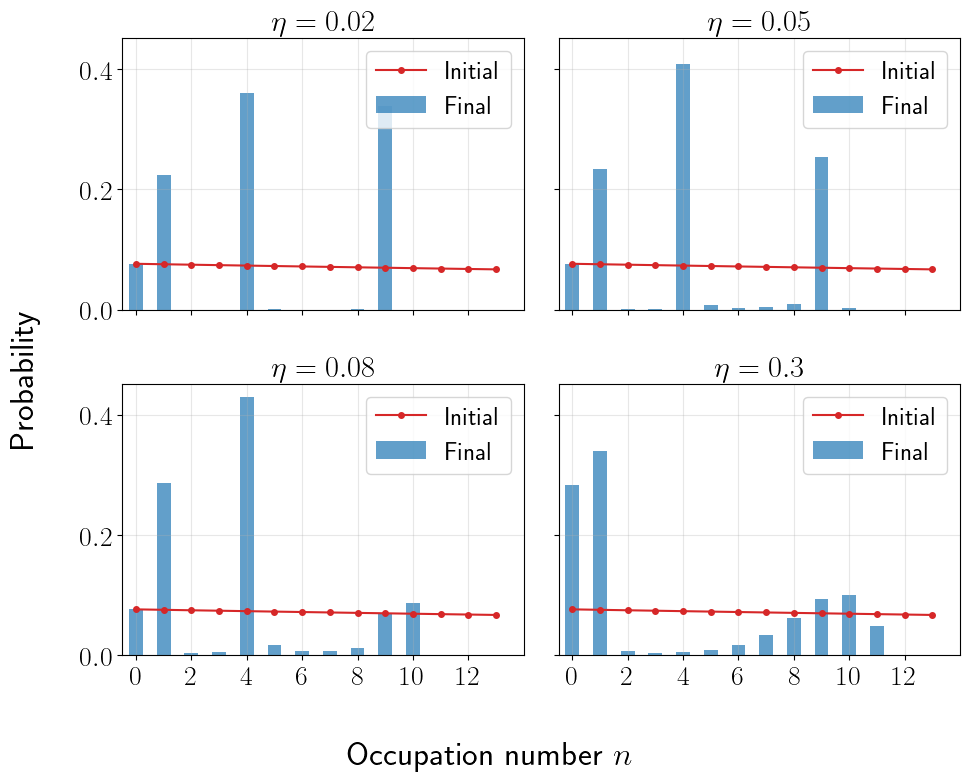

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# from qutip import *

# # Define system parameters
# Delta = 1.0  # Detuning
# nu = 1.0     # Motional frequency
# Omega=0.001  # Rabi frequency
# eta = 0.05    # Lamb-Dicke parameter
# n_thermal = 1  # Average thermal phonon number
# n0 = 1
# gamma = 1000  # Spin relaxation
# beta = 0.01    # Inverse temperature
# kT = 1.0      # Boltzmann constant times temperature
# tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration

# # Define operators
# N = 14  # Truncation for the Fock space

# # QHO operators
# a = destroy(N)  # Annihilation operator
# a_dag = a.dag()  # Creation operator
# xop = a + a_dag # Position operator

# # Spin operators
# sz = sigmaz()
# s_plus = sigmap()
# s_minus = sigmam()

# # Full size operators
# s_z_full = tensor(sz, qeye(N))
# s_plus_full = tensor(s_plus, qeye(N))
# a_full = tensor(qeye(2), a)
# a_dag_full = tensor(qeye(2), a_dag)
# s_minus_full = tensor(s_minus, qeye(N))

# # Displaced hamiltonian operator
# D_op = tensor(qeye(2), displace(N, 1j * eta))

# # Full Hamiltonian (Eq. 1)
# # We set detuning Delta = nu to drive the Red Sideband
# H_pulse = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#           0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())

# # Hamiltonian (Free evolution for Dissipation)
# H_diss = Delta*s_z_full/2 + nu*a_dag_full*a_full

# # The density matrix in the master equation is displaced due to recoil from spontaneous emission.
# # We can include this effect in the collapse operators by integrating over the angular distribution of emission
# # in a dipolar transition.


# # --- Collapse Operators for Dissipation with recoil ---
# cosmax = 100
# cosal = np.arange(-cosmax, cosmax + 1) / cosmax
# W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
# W = W / np.sum(W)
# G = gamma / 2  # This is Γ/2 in the master equation
# tg = 2 / G  # Dissipation duration adjusted for rates
# c_ops = []
# for i, c in enumerate(cosal):
#     U_mot = (1j * c * eta * xop).expm()
#     U_full = tensor(qeye(2), U_mot)
#     c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# # Add sigma_minus decay without recoil (optional, for comparison)
# c_ops.append(np.sqrt(gamma) * s_minus_full)
# # --- Construct Liouvillians ---
# # 1. Pulse Step: Coherent RSB drive, NO dissipation (or minimal?)
# # Typically only Unitary part active during pulse
# L_pulse = liouvillian(H_pulse, []) 

# # 2. Dissipation Step: No Drive, ONLY Dissipation (Optical Pumping)
# # H = 0 (or H0), c_ops active
# L_diss = liouvillian(H_diss, c_ops)

# # --- Propagators ---
# # Propagator for Pulse step (duration tau)
# prop_pulse = (L_pulse * tau).expm()

# # Propagator for Dissipation step (duration tg)
# prop_diss = (L_diss * tg).expm()

# # Combined Propagator for one cycle (Pulse -> Dissipation)
# prop_cycle = prop_diss * prop_pulse 


# # --- Simulation ---
# num_pulses = 30 # Number of cycles
# times_sim = np.arange(num_pulses + 1) # Just integer steps for cycles

# # Initial state
# thermal_state = (-beta * nu * a_dag * a / kT).expm()
# thermal_state = thermal_state / thermal_state.tr() 
# ground_state = basis(2, 1) 
# initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# # Storage
# occupancies = np.zeros((num_pulses + 1, N))
# rho_vec = operator_to_vector(initial_state)

# # Initial occupancy
# rho_mat = vector_to_operator(rho_vec)
# occupancies[0, :] = rho_mat.ptrace(1).diag().real

# # Evolve step-by-step
# current_rho_vec = rho_vec
# for k in range(1, num_pulses + 1):
#     current_rho_vec = prop_cycle * current_rho_vec
    
#     # Store
#     rho_mat = vector_to_operator(current_rho_vec)
#     occupancies[k, :] = rho_mat.ptrace(1).diag().real


# Plot the occupancy of all motional states over cycles
# plt.figure()
# for n in range(N):
#     plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
# plt.xlabel('Pulse Cycle')
# plt.ylabel('Occupancy')
# plt.title('Occupancy vs Cooling Cycles')
# plt.legend()
# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from qutip import *

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 18
})

# Define system parameters
Delta = 1.0  # Detuning
nu = 1.0     # Motional frequency
Omega=0.001  # Rabi frequency
eta = 0.05    # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
beta = 0.01    # Inverse temperature
kT = 100      # Boltzmann constant times temperature
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
N = 14
num_pulses = 30

eta_values = [0.02, 0.05, 0.08, 0.3]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True, sharex=True)
axes = axes.flatten()

for idx, eta in enumerate(eta_values):
    tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))

    # QHO operators
    a = destroy(N)
    a_dag = a.dag()
    xop = a + a_dag

    # Spin operators
    sz = sigmaz()
    s_plus = sigmap()
    s_minus = sigmam()
    s_y = sigmay()
    s_x = sigmax()

    # Full size operators
    s_z_full = tensor(sz, qeye(N))
    s_plus_full = tensor(s_plus, qeye(N))
    s_minus_full = tensor(s_minus, qeye(N))
    s_y_full = tensor(s_y, qeye(N))
    a_full = tensor(qeye(2), a)
    a_dag_full = tensor(qeye(2), a_dag)
    s_x_full = tensor(s_x, qeye(N))

    D_op = tensor(qeye(2), displace(N, 1j * eta))

    # Full Hamiltonian (Eq. 1)
    # We set detuning Delta = nu to drive the Red Sideband
    H_pulse = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
            0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())

    # Hamiltonian (Free evolution for Dissipation)
    H_diss = Delta*s_z_full/2 + nu*a_dag_full*a_full

    # The density matrix in the master equation is displaced due to recoil from spontaneous emission.
    # We can include this effect in the collapse operators by integrating over the angular distribution of emission
    # in a dipolar transition.


    # --- Collapse Operators for Dissipation with recoil ---
    cosmax = 100
    cosal = np.arange(-cosmax, cosmax + 1) / cosmax
    W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
    W = W / np.sum(W)
    G = gamma / 2  # This is Γ/2 in the master equation
    tg = 2 / G  # Dissipation duration adjusted for rates
    c_ops = []
    for i, c in enumerate(cosal):
        U_mot = (1j * c * eta * xop).expm()
        U_full = tensor(qeye(2), U_mot)
        c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

    # Add sigma_minus decay without recoil (optional, for comparison)
    c_ops.append(np.sqrt(gamma) * s_minus_full)
    # --- Construct Liouvillians ---
    # 1. Pulse Step: Coherent RSB drive, NO dissipation (or minimal?)
    # Typically only Unitary part active during pulse
    L_pulse = liouvillian(H_pulse, []) 

    # 2. Dissipation Step: No Drive, ONLY Dissipation (Optical Pumping)
    # H = 0 (or H0), c_ops active
    L_diss = liouvillian(H_diss, c_ops)

    # --- Propagators ---
    # Propagator for Pulse step (duration tau)
    prop_pulse = (L_pulse * tau).expm()

    # Propagator for Dissipation step (duration tg)
    prop_diss = (L_diss * tg).expm()

    # Combined Propagator for one cycle (Pulse -> Dissipation)
    prop_cycle = prop_diss * prop_pulse 

    # Initial state
    thermal_state = (-nu * a_dag * a / kT).expm()
    thermal_state = thermal_state / thermal_state.tr()
    ground_state = basis(2, 1)
    initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

    occupancies = np.zeros((num_pulses + 1, N))
    rho_vec = operator_to_vector(initial_state)
    rho_mat = vector_to_operator(rho_vec)
    occupancies[0, :] = rho_mat.ptrace(1).diag().real

    current_rho_vec = rho_vec
    for k in range(1, num_pulses + 1):
        current_rho_vec = prop_cycle * current_rho_vec
        rho_mat = vector_to_operator(current_rho_vec)
        occupancies[k, :] = rho_mat.ptrace(1).diag().real

    # Plot
    ax = axes[idx]
    p_initial = occupancies[0, :]
    p_final = occupancies[-1, :]
    n_states = np.arange(N)
    ax.plot(n_states, p_initial, 'o-', color='tab:red', markersize=4, label='Initial')
    ax.bar(n_states, p_final, width=0.5, alpha=0.7, color='tab:blue', label='Final')
    ax.set_title(rf'$\eta = {eta}$')
    ax.set_xlim(-0.5, 14)
    ax.set_xticks(np.arange(0, N, 2))
    ax.tick_params(axis='both')
    ax.legend()
    ax.grid(True, alpha=0.3)

    print(f"eta={eta} done — n_bar initial={np.dot(n_states, p_initial):.3f}, final={np.dot(n_states, p_final):.3f}")

fig.supxlabel('Occupation number $n$')
fig.supylabel('Probability')
# fig.suptitle('Cooling in the Lamb-Dicke Regime', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('figure_delakouras.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

### Simulated vs ideal

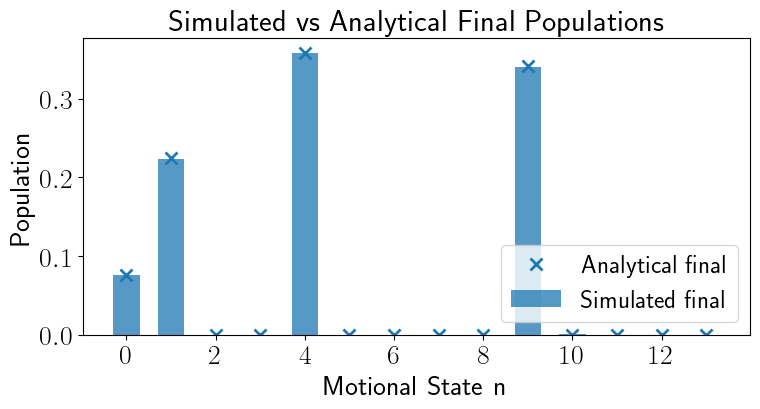

Sum simulated final:  1.000000
Sum analytical final: 1.000000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 1.0  # Detuning
nu = 1.0     # Motional frequency
Omega = 0.001  # Rabi frequency
eta = 0.01    # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
beta = 0.01    # Inverse temperature
kT = 1.0      # Boltzmann constant times temperature
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration

# Define operators
N = 14  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))

# Displaced hamiltonian operator
D_op = tensor(qeye(2), displace(N, 1j * eta))

# Full Hamiltonian (Eq. 1)
H_pulse = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# --- Collapse Operators for Dissipation with recoil ---
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2  # This is Γ/2 in the master equation
tg = 2 / G  # Dissipation duration adjusted for rates
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# Add sigma_minus decay without recoil (optional, for comparison)
c_ops.append(np.sqrt(gamma) * s_minus_full)

# --- Construct Liouvillians ---
L_pulse = liouvillian(H_pulse, [])
L_diss = liouvillian(H_diss, c_ops)

# --- Propagators ---
prop_pulse = (L_pulse * tau).expm()
prop_diss = (L_diss * tg).expm()
prop_cycle = prop_diss * prop_pulse

# --- Simulation ---
num_pulses = 30  # Number of cycles
times_sim = np.arange(num_pulses + 1)

# Initial state
thermal_state = (-beta * nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
initial_probs = np.real(np.array(thermal_state.diag())).flatten()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)

# Initial occupancy
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

# Evolve step-by-step
current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real

# Simulated final populations
p_motional_final = occupancies[-1, :]

# Analytical final populations (trap-bin mapping)
expected_probs = np.zeros(N)
m = 0
while True:
    trap_idx = n0 * m**2
    next_trap_idx = n0 * (m + 1)**2

    # Stop if the trap state is beyond our truncation
    if trap_idx >= N:
        break

    # Define range for this trap bin: [trap_idx, next_trap_idx)
    start_n = trap_idx
    end_n = min(next_trap_idx, N)

    # Sum initial populations in this range
    if start_n < N:
        sum_p = np.sum(initial_probs[start_n:end_n])
        expected_probs[trap_idx] = sum_p

    m += 1

# Plot: simulated vs analytical final populations
n_vals = np.arange(N)
plt.figure(figsize=(8, 4.5))
plt.bar(n_vals, p_motional_final, width=0.6, label='Simulated final', alpha=0.75)
plt.plot(n_vals, expected_probs, 'x', markersize=8, markeredgewidth=2, label='Analytical final')
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('Simulated vs Analytical Final Populations')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Sum simulated final:  {np.sum(p_motional_final):.6f}')
print(f'Sum analytical final: {np.sum(expected_probs):.6f}')

### 3. New pulse sequence


* RF dipolar pulse to the trapped ion
* Y pulse of pi/2
* x pulse of length $\tau$
* undo y pulse
* Relacation to ground spin state
* undo displacement RF pulse

In this frame, $\Omega = \nu$ and $\Delta = 0$

#### 3.1 Testing each pulse separately
- RF dipolar pulse:
$$
H_{RF} = i\frac{RF\_strength}{2} (a - a^{\dagger})
$$
where $RF\_strength$ is the strength of the RF dipolar coupling, set to $\eta$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 0  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
Omega = nu  # Rabi frequency
Omega_y = 1*Omega  # Rabi frequency for Y pulse
eta = 0.2    # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
beta = 0.01    # Inverse temperature
kT = 1.0      # Boltzmann constant times temperature
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
print(f"Pulse duration tau: {tau}")
# Define operators
N = 20  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N, 1j * eta))

"""Hamiltonians for pulse and dissipation steps defined above."""

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# --- Pulses for the new sequence ---

# 1) RF dipolar pulse of i*eta/2
H_rf = (RF_strength / 2) * (a_full - a_dag_full)
rf_duration = -1j * eta / RF_strength
L_rf = liouvillian(H_rf, [])
prop_rf = (L_rf * rf_duration).expm()
# undo RF
prop_rf_undo = (-L_rf * rf_duration).expm()

# Test the displacement of this pulse on a vacuum motional state
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), basis(N, 0) * basis(N, 0).dag())

print("Initial motional state populations:", initial_state.ptrace(1).diag().real)
print("Expected displacement amplitude:", eta / 2)

initial_state_vec = operator_to_vector(initial_state)
final_state_vec = prop_rf * initial_state_vec

final_state = vector_to_operator(final_state_vec)
print("Final motional state populations after RF pulse:", final_state.ptrace(1).diag().real)
# Calculate the expected displaced state populations for comparison
displaced_state = displace(N, -1j * eta / 2) * basis(N, 0)
expected_populations = np.abs(displaced_state.full().flatten())**2
print("Expected motional state populations after displacement:", expected_populations)


Pulse duration tau: 31.41592653589793
Initial motional state populations: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Expected displacement amplitude: 0.1
Final motional state populations after RF pulse: [ 9.90049834e-01 -9.90049834e-03  4.95024917e-05 -1.65008306e-07
  4.12520764e-10 -8.25041528e-13  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
Expected motional state populations after displacement: [9.90049834e-01 9.90049834e-03 4.95024917e-05 1.65008306e-07
 4.12520764e-10 8.25041528e-13 1.37506921e-15 1.96438459e-18
 2.45548074e-21 2.72831193e-24 2.72831193e-27 2.48028359e-30
 2.06690320e-33 1.58992226e-36 1.13561496e-39 7.57264145e-43
 4.76457037e-46 2.97961239e-49 2.35329623e-52 4.16225504e-55]


- Y(π/2) pulse on the spin
$$
H_{Y} = \frac{\Delta}{2}\sigma_{z} + \nu aa^{\dagger} + \frac{i\Omega_{y}}{2}\sigma_{y} [\sigma^{+}D(i\eta) - \sigma^{-}D^{\dagger}(i\eta)]
$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 0  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
Omega = nu  # Rabi frequency
Omega_y = 1*Omega  # Rabi frequency for Y pulse
eta = 0.2    # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
beta = 0.01    # Inverse temperature
kT = 1.0      # Boltzmann constant times temperature
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
print(f"Pulse duration tau: {tau}")
# Define operators
N = 20  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N, 1j * eta))

"""Hamiltonians for pulse and dissipation steps defined above."""

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

 
# 2) Y(π/2) pulse on the spin, same as H_pulse but with phase shift on the sigmas
H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega_y * (1j * s_plus_full * D_op - 1j * s_minus_full * D_op.dag())
y_duration = np.pi / (2 *Omega_y)
L_y = liouvillian(H_y, [])
prop_y = (L_y * y_duration).expm()


# Test Y(π/2) pulse on spin-up state
ground_state = basis(2, 0)
initial_state = tensor(ground_state * ground_state.dag(), basis(N, 0) * basis(N, 0).dag())
initial_state_vec = operator_to_vector(initial_state)

print("Initial <s_z>:", expect(s_z_full, initial_state))
print("Initial <s_y>:", expect(s_y_full, initial_state))
print("Initial <s_x>:", expect(s_x_full, initial_state))

final_state_vec = prop_y * initial_state_vec
final_state = vector_to_operator(final_state_vec)

print("Final <s_z> after Y(π/2):", expect(s_z_full, final_state))
print("Final <s_y> after Y(π/2):", expect(s_y_full, final_state))
print("Final <s_x> after Y(π/2):", expect(s_x_full, final_state))

Pulse duration tau: 31.41592653589793
Initial <s_z>: 1.0
Initial <s_y>: 0.0
Initial <s_x>: 0.0
Final <s_z> after Y(π/2): 0.008031587251896346
Final <s_y> after Y(π/2): 0.014180090177442336
Final <s_x> after Y(π/2): -0.9831366596423945


- X $\tau$ pulse on the spin:
$$
H_{X} = \frac{\Delta}{2}\sigma_{z} + \nu aa^{\dagger} + \frac{i\Omega}{2}[\sigma^{+}D(i\eta) - \sigma^{-}D^{\dagger}(i\eta)]
$$
which is applied for a time $\tau = \frac{\pi}{\eta \Omega}$, which should ideally produce a displacement of $-i\eta$ in the motional state.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 0  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
Omega = nu  # Rabi frequency
Omega_y = 1*Omega  # Rabi frequency for Y pulse
eta = 0.01    # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
beta = 0.01    # Inverse temperature
kT = 1.0      # Boltzmann constant times temperature
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
print(f"Pulse duration tau: {tau}")
# Define operators
N = 20  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N, 1j * eta))

"""Hamiltonians for pulse and dissipation steps defined above."""

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full
 
 
# 3) X(τ) pulse on the spin, same as H_pulse but with different phase
H_x = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
L_x = liouvillian(H_x, [])
prop_x = (L_x * tau).expm()

# Test the X pulse on spin-up state
ground_state = basis(2, 0)
initial_state = tensor(ground_state * ground_state.dag(), basis(N, 0) * basis(N, 0).dag())
initial_state_vec = operator_to_vector(initial_state)

print("Initial <s_z>:", expect(s_z_full, initial_state))
print("Initial <s_y>:", expect(s_y_full, initial_state))
print("Initial <s_x>:", expect(s_x_full, initial_state))
final_state_vec = prop_x * initial_state_vec
final_state = vector_to_operator(final_state_vec)
print("Final <s_z> after X(τ):", expect(s_z_full, final_state))
print("Final <s_y> after X(τ):", expect(s_y_full, final_state))
print("Final <s_x> after X(τ):", expect(s_x_full, final_state))

Pulse duration tau: 628.3185307179587
Initial <s_z>: 1.0
Initial <s_y>: 0.0
Initial <s_x>: 0.0
Final <s_z> after X(τ): -0.999992085797362
Final <s_y> after X(τ): 6.980511648096892e-08
Final <s_x> after X(τ): 1.0021448000009876e-05


#### 3.2 Full sequence simulation

Pulse duration tau: 125663.70614359171


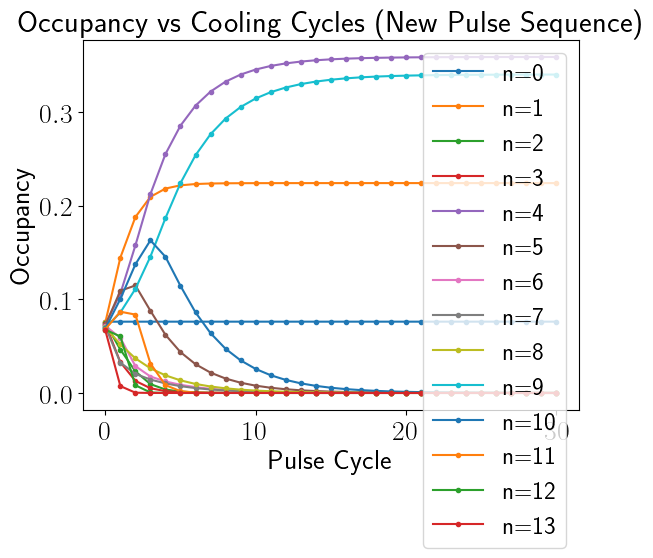

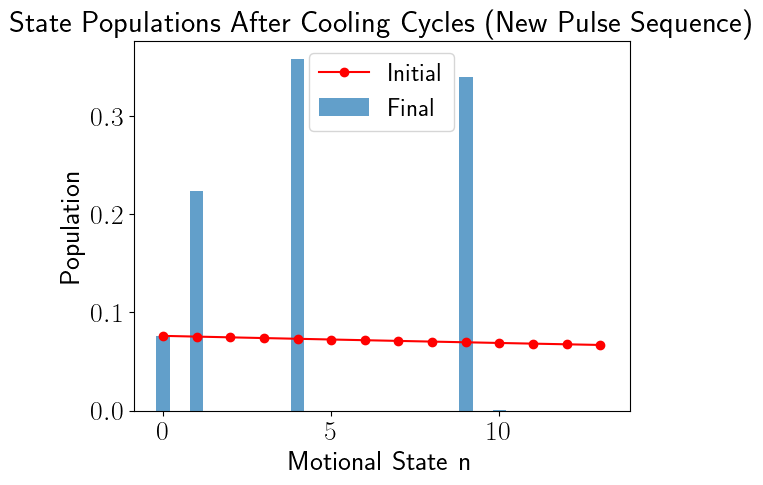

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 0  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
Omega = 0.001 * nu  # Rabi frequency
Omega_y = 100  # Rabi frequency for Y pulse
eta = 0.05   # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
kT = 1.0      # Boltzmann constant times temperature
beta = 0.01    # Inverse temperature
tau =  2*np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
print(f"Pulse duration tau: {tau}")
# Define operators
N = 14  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N,1j*eta))

"""Hamiltonians for pulse and dissipation steps defined above."""

# Full Hamiltonian (Eq. 1) – not directly used in the new sequence,
## but kept for reference
# H_pulse = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#           0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())

# Keep for reference
# H_pulse = nu * a_dag_full * a_full + 1j * 0.5 * eta * Omega * s_x_full * (a_full - a_dag_full)  + Omega/2 * s_z_full

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# --- Pulses for the new sequence ---

# 1) RF dipolar pulse of i*eta/2
H_rf = (RF_strength / 2) * (a_full + a_dag_full)
rf_duration = eta / RF_strength
L_rf = liouvillian(H_rf, [])
prop_rf = (L_rf * rf_duration).expm()
# undo RF
prop_rf_undo = (-L_rf * rf_duration).expm()
 
# 2) Y(π/2) pulse on the spin, same as H_pulse but with phase shift on the sigmas
#H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#          0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
H_y = 0.5 * Omega_y *s_y_full
y_duration = np.pi / (2 *Omega_y)
L_y = liouvillian(H_y, [])
prop_y = (L_y * y_duration).expm()
# Undo Y(π/2)
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * y_duration).expm()
 
 
# 3) X(τ) pulse on the spin, same as H_pulse but with different phase
#H_x = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#          0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
H_x = 0.5 * nu * s_x_full + nu * a_dag_full * a_full + \
          0.5 * 1j * Omega * eta * s_z_full * (a_dag_full - a_full)
L_x = liouvillian(H_x, [])
prop_x = (L_x * tau).expm()

# --- Collapse Operators for Dissipation with recoil ---
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2  # This is Γ/2 in the master equation
tg = 2 / G  # Dissipation duration adjusted for rates
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# Add sigma_minus decay without recoil (optional, for comparison)
c_ops.append(np.sqrt(gamma) * s_minus_full)

# --- Liouvillian and propagator for dissipation step ---
L_diss = liouvillian(H_diss, c_ops)
prop_diss = (L_diss * tg).expm()

# Combined Propagator for one cooling cycle:
## RF dipolar pulse -> Y(π/2) -> X(τ) -> undo Y -> relaxation -> undo RF
prop_cycle = prop_diss  * prop_y_undo * prop_x * prop_y

# --- Simulation ---
num_pulses = 30  # Number of cycles
times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles

# Initial state: spin in ground, motion thermal
thermal_state = (- beta * nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)

# Initial occupancy
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

# Evolve step-by-step under the new pulse sequence
current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec

    # Store
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real


# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies[0, :]
p_motional_final = occupancies[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial' , color='red')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

### Paper figure 1

eta=0.05, RF pulse duration: 0.05
eta=0.05, Y(π/2) pulse duration: 0.015707963267948967
eta=0.05, X(τ) pulse duration: 125.66370614359172
eta=0.05 done — n_bar initial=6.338, final=4.682
eta=0.008, RF pulse duration: 0.008
eta=0.008, Y(π/2) pulse duration: 0.015707963267948967
eta=0.008, X(τ) pulse duration: 785.3981633974482
eta=0.008 done — n_bar initial=6.338, final=4.728
eta=0.1, RF pulse duration: 0.1
eta=0.1, Y(π/2) pulse duration: 0.015707963267948967
eta=0.1, X(τ) pulse duration: 62.83185307179586
eta=0.1 done — n_bar initial=6.338, final=4.503
eta=0.2, RF pulse duration: 0.2
eta=0.2, Y(π/2) pulse duration: 0.015707963267948967
eta=0.2, X(τ) pulse duration: 31.41592653589793
eta=0.2 done — n_bar initial=6.338, final=4.077


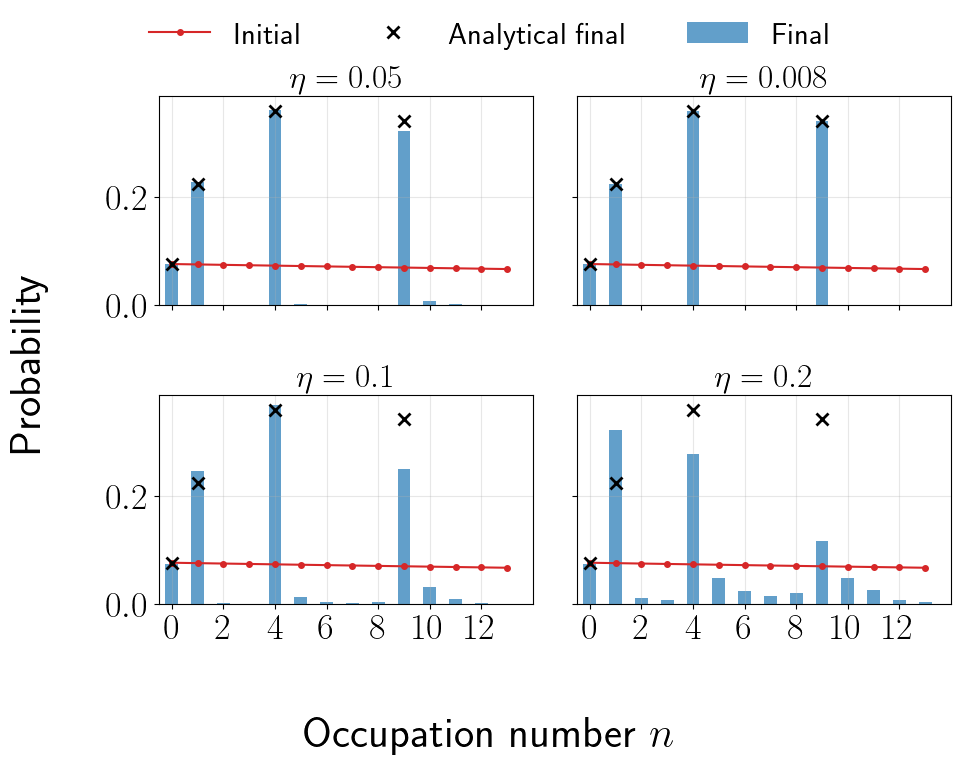

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 26,
    'axes.titlesize': 24,
    'axes.labelsize': 26,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 22
})

# Define system parameters
Delta = 0
RF_strength = 1
nu = 1.0
Omega = nu
Omega_y = 100
n_thermal = 1
n0 = 1
gamma = 1000
kT = 100
N = 14
num_pulses = 30

eta_values = [0.05, 0.008, 0.1, 0.2]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True, sharex=True)
axes = axes.flatten()

legend_handles = None
legend_labels = None

for idx, eta in enumerate(eta_values):
    tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))

    # QHO operators
    a = destroy(N)
    a_dag = a.dag()
    xop = a + a_dag

    # Spin operators
    sz = sigmaz()
    s_plus = sigmap()
    s_minus = sigmam()
    s_y = sigmay()
    s_x = sigmax()

    # Full size operators
    s_z_full = tensor(sz, qeye(N))
    s_plus_full = tensor(s_plus, qeye(N))
    s_minus_full = tensor(s_minus, qeye(N))
    s_y_full = tensor(s_y, qeye(N))
    a_full = tensor(qeye(2), a)
    a_dag_full = tensor(qeye(2), a_dag)
    s_x_full = tensor(s_x, qeye(N))

    D_op = tensor(qeye(2), displace(N, 1j * eta))

    H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

    # 1) RF dipolar pulse
    H_rf = (RF_strength / 2) * (a_full + a_dag_full)
    rf_duration = eta / RF_strength
    print(f"eta={eta}, RF pulse duration: {rf_duration}")
    L_rf = liouvillian(H_rf, [])
    prop_rf = (L_rf * rf_duration).expm()
    prop_rf_undo = (-L_rf * rf_duration).expm()

    # 2) Y(π/2) pulse
    # H_y = 0.5 * Omega_y * s_y_full
    H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
    y_duration = np.pi / (2 * Omega_y)
    print(f"eta={eta}, Y(π/2) pulse duration: {y_duration}")
    L_y = liouvillian(H_y, [])
    prop_y = (L_y * y_duration).expm()
    L_y_undo = liouvillian(-H_y, [])
    prop_y_undo = (L_y_undo * y_duration).expm()

    # 3) X(τ) pulse
    # H_x = 0.5 * nu * s_x_full + nu * a_dag_full * a_full + \
    #           0.5 * 1j * Omega * eta * s_z_full * (a_dag_full - a_full)
    H_x = 0.5 * Delta * s_x_full + nu * a_dag_full * a_full + 0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
    print(f"eta={eta}, X(τ) pulse duration: {tau}")
    L_x = liouvillian(H_x, [])
    prop_x = (L_x * tau).expm()

    # Collapse operators with recoil
    cosmax = 100
    cosal = np.arange(-cosmax, cosmax + 1) / cosmax
    W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
    W = W / np.sum(W)
    G = gamma / 2
    tg = 2 / G
    c_ops = []
    for i, c in enumerate(cosal):
        U_mot = (1j * c * eta * xop).expm()
        U_full = tensor(qeye(2), U_mot)
        c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))
    c_ops.append(np.sqrt(gamma) * s_minus_full)

    # Propagators
    L_diss = liouvillian(H_diss, c_ops)
    prop_diss = (L_diss * tg).expm()
    prop_cycle = prop_diss * prop_rf_undo * prop_y_undo * prop_x * prop_y * prop_rf

    # Initial state
    thermal_state = (-nu * a_dag * a / kT).expm()
    thermal_state = thermal_state / thermal_state.tr()
    ground_state = basis(2, 1)
    initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

    occupancies = np.zeros((num_pulses + 1, N))
    rho_vec = operator_to_vector(initial_state)
    rho_mat = vector_to_operator(rho_vec)
    occupancies[0, :] = rho_mat.ptrace(1).diag().real

    current_rho_vec = rho_vec
    for k in range(1, num_pulses + 1):
        current_rho_vec = prop_cycle * current_rho_vec
        rho_mat = vector_to_operator(current_rho_vec)
        occupancies[k, :] = rho_mat.ptrace(1).diag().real

    # Plot
    ax = axes[idx]
    p_initial = occupancies[0, :]
    p_final = occupancies[-1, :]
    n_states = np.arange(N)

    # Analytical final populations (trap-bin mapping)
    initial_probs = p_initial
    expected_probs = np.zeros(N)
    m = 0
    while True:
        trap_idx = int(n0 * m**2)
        next_trap_idx = int(n0 * (m + 1)**2)

        # Stop if the trap state is beyond our truncation
        if trap_idx >= N:
            break

        # Define range for this trap bin: [trap_idx, next_trap_idx)
        start_n = trap_idx
        end_n = min(next_trap_idx, N)

        # Sum initial populations in this range
        if start_n < N:
            sum_p = np.sum(initial_probs[start_n:end_n])
            expected_probs[trap_idx] = sum_p

        m += 1
    trap_indices = np.nonzero(expected_probs)[0]

    ax.plot(n_states, p_initial, 'o-', color='tab:red', markersize=4, label='Initial')
    ax.bar(n_states, p_final, width=0.5, alpha=0.7, color='tab:blue', label='Final')
    ax.plot(trap_indices, expected_probs[trap_indices], linestyle='None', marker='x', color='k',
            markersize=8, markeredgewidth=2, label='Analytical final')

    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_title(rf'$\eta = {eta}$')
    ax.set_xlim(-0.5, 14)
    ax.set_xticks(np.arange(0, N, 2))
    ax.tick_params(axis='both')
    ax.grid(True, alpha=0.3)

    print(f"eta={eta} done — n_bar initial={np.dot(n_states, p_initial):.3f}, final={np.dot(n_states, p_final):.3f}")

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc='upper center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 0.96))

fig.supxlabel('Occupation number $n$')
fig.supylabel('Probability')
# fig.suptitle('Cooling in the Lamb-Dicke Regime', fontsize=16, y=1.01)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('figures/figure_2.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()

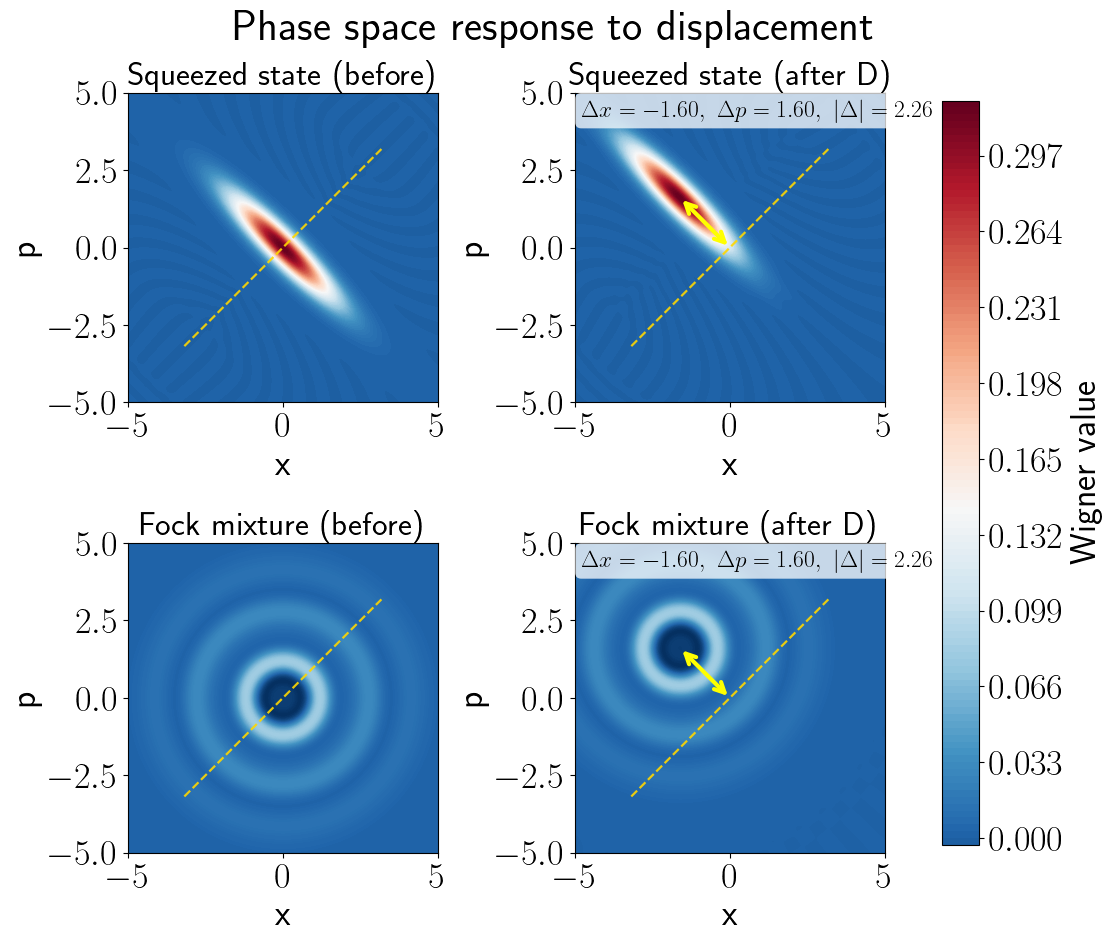

In [9]:
# --- Wigner comparison: squeezed state vs Fock-mixture (before/after displacement) ---

def _get_final_mixture_probs():
    # 1) Use latest simulation storage if available
    if 'occupancies' in globals():
        p = np.array(occupancies[-1, :], dtype=float).flatten()
        return p, "from `occupancies[-1, :]`"

    raise RuntimeError("No final Fock-mixture populations found in notebook memory.")

# Get final mixture populations
p_mix, source_label = _get_final_mixture_probs()
p_mix = np.clip(p_mix, 0, None)
p_mix = p_mix / p_mix.sum()

# Phase-space / Hilbert-space settings
N_mix = len(p_mix)
N_wig = max(40, N_mix)         # larger cutoff for smooth Wigner plots
xvec = np.linspace(-5, 5, 251)

# Choose the squeezed-axis orientation explicitly.
# In qutip, squeeze(N, z) uses z = r * exp(i * phi), and the ellipse is rotated by phi / 2.
r = 0.8
squeeze_phase = np.pi / 2
squeezed_axis_angle = squeeze_phase / 2

# Displace parallel to the squeezed quadrature.
# To compare against the anti-squeezed direction later, add np.pi / 2 here.
displacement_magnitude = 1.6
displacement_phase_offset = np.pi / 2
alpha = displacement_magnitude * np.exp(1j * (squeezed_axis_angle + displacement_phase_offset))

# --- Squeezed state (pure) ---
psi_sq = squeeze(N_wig, r * np.exp(1j * squeeze_phase)) * basis(N_wig, 0)
rho_sq = ket2dm(psi_sq)

D = displace(N_wig, alpha)
rho_sq_disp = D * rho_sq * D.dag()

# --- Fock mixture from final populations ---
p_pad = np.zeros(N_wig)
p_pad[:N_mix] = p_mix
rho_mix = Qobj(np.diag(p_pad), dims=[[N_wig], [N_wig]])
rho_mix_disp = D * rho_mix * D.dag()

# Phase-space centers (used for shift arrows)
a_wig = destroy(N_wig)
xop_wig = (a_wig + a_wig.dag()) / np.sqrt(2)
pop_wig = (-1j) * (a_wig - a_wig.dag()) / np.sqrt(2)

def _center_xp(rho):
    return float(expect(xop_wig, rho)), float(expect(pop_wig, rho))

sq_before = _center_xp(rho_sq)
sq_after = _center_xp(rho_sq_disp)
mix_before = _center_xp(rho_mix)
mix_after = _center_xp(rho_mix_disp)

# Wigner functions
W_sq = wigner(rho_sq, xvec, xvec)
W_sq_disp = wigner(rho_sq_disp, xvec, xvec)
W_mix = wigner(rho_mix, xvec, xvec)
W_mix_disp = wigner(rho_mix_disp, xvec, xvec)

# Common color scaling
vmin = min(W_sq.min(), W_sq_disp.min(), W_mix.min(), W_mix_disp.min())
vmax = max(W_sq.max(), W_sq_disp.max(), W_mix.max(), W_mix_disp.max())

fig, axs = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

im0 = axs[0, 0].contourf(xvec, xvec, W_sq, 120, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axs[0, 0].set_title('Squeezed state (before)')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_ylabel('p')

axs[0, 1].contourf(xvec, xvec, W_sq_disp, 120, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axs[0, 1].set_title('Squeezed state (after D)')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('p')

axs[1, 0].contourf(xvec, xvec, W_mix, 120, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axs[1, 0].set_title('Fock mixture (before)')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('p')

axs[1, 1].contourf(xvec, xvec, W_mix_disp, 120, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axs[1, 1].set_title('Fock mixture (after D)')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('p')

def _add_shift_arrow(ax, before, after):
    x0, p0 = before
    x1, p1 = after
    dx, dp = (x1 - x0), (p1 - p0)
    ax.annotate("", xy=(x1, p1), xytext=(x0, p0),
                arrowprops=dict(arrowstyle="<->", lw=3, color="yellow", mutation_scale=18))
    label = rf"$\Delta x={dx:.2f},\ \Delta p={dp:.2f},\ |\Delta|={np.hypot(dx, dp):.2f}$"
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75),
            fontsize=17)

def _add_axis_guide(ax, angle, length=4.5):
    dx = length * np.cos(angle)
    dp = length * np.sin(angle)
    ax.plot([-dx, dx], [-dp, dp], '--', color='gold', lw=1.6, alpha=0.9)

for ax in axs.flat:
    _add_axis_guide(ax, squeezed_axis_angle)

# Add shift arrows on the displaced panels
_add_shift_arrow(axs[0, 1], sq_before, sq_after)
_add_shift_arrow(axs[1, 1], mix_before, mix_after)

for ax in axs.flat:
    ax.set_aspect('equal')

cbar = fig.colorbar(im0, ax=axs, shrink=0.92, pad=0.02)
cbar.set_label('Wigner value')

fig.suptitle('Phase space response to displacement', y=1.04)
fig.savefig('figures/figure_0.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()

### Figure 2

Omega=0.5 done — n_bar initial=6.498, final=4.695
Omega=1 done — n_bar initial=6.498, final=4.791
Omega=4 done — n_bar initial=6.498, final=6.497
Omega=8 done — n_bar initial=6.498, final=6.491


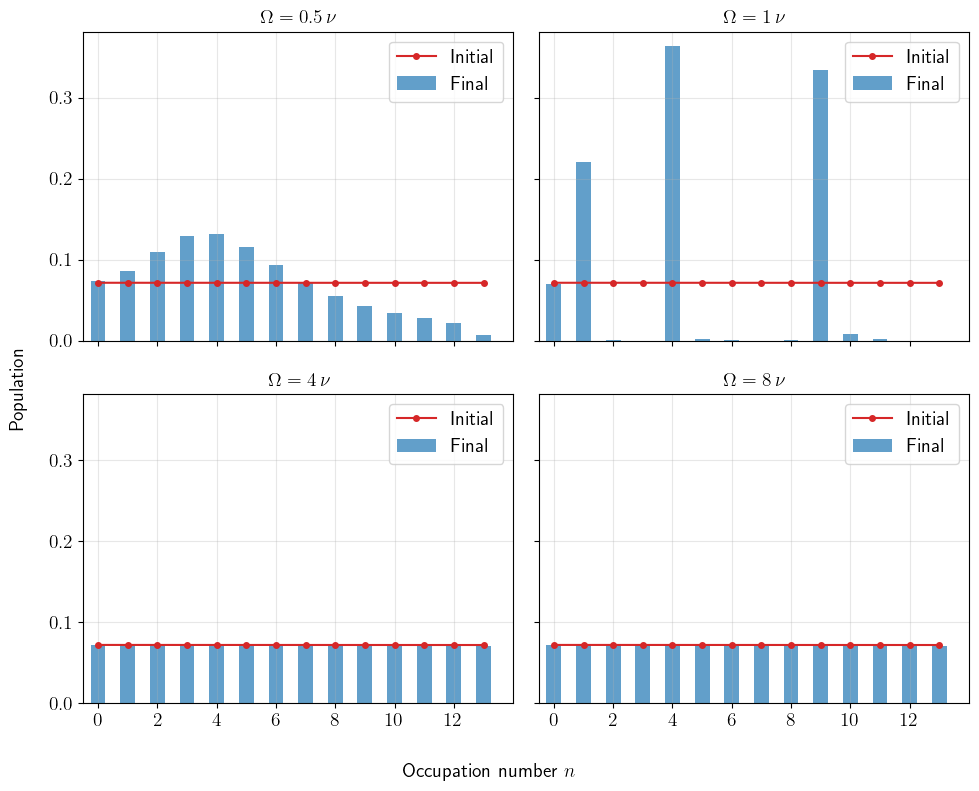

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Define system parameters
Delta = 0
RF_strength = 1
nu = 1.0
eta = 0.05
Omega_y = 100
n_thermal = 1
n0 = 1
gamma = 1000
kT = 100
beta = 0.01  # Inverse temperature
N = 14
num_pulses = 60

Omega_values = [0.5, 1, 4, 8]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True, sharex=True)
axes = axes.flatten()

for idx, Omega in enumerate(Omega_values):
    tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))

    # QHO operators
    a = destroy(N)
    a_dag = a.dag()
    xop = a + a_dag

    # Spin operators
    sz = sigmaz()
    s_plus = sigmap()
    s_minus = sigmam()
    s_y = sigmay()
    s_x = sigmax()

    # Full size operators
    s_z_full = tensor(sz, qeye(N))
    s_plus_full = tensor(s_plus, qeye(N))
    s_minus_full = tensor(s_minus, qeye(N))
    s_y_full = tensor(s_y, qeye(N))
    a_full = tensor(qeye(2), a)
    a_dag_full = tensor(qeye(2), a_dag)
    s_x_full = tensor(s_x, qeye(N))

    D_op = tensor(qeye(2), displace(N, 1j * eta))

    H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

    # 1) RF dipolar pulse
    H_rf = (RF_strength / 2) * (a_full + a_dag_full)
    rf_duration = eta / RF_strength
    L_rf = liouvillian(H_rf, [])
    prop_rf = (L_rf * rf_duration).expm()
    prop_rf_undo = (-L_rf * rf_duration).expm()

    # 2) Y(π/2) pulse
    # H_y = 0.5 * Omega_y * s_y_full
    H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
    y_duration = np.pi / (2 * Omega_y)
    L_y = liouvillian(H_y, [])
    prop_y = (L_y * y_duration).expm()
    L_y_undo = liouvillian(-H_y, [])
    prop_y_undo = (L_y_undo * y_duration).expm()

    # 3) X(τ) pulse
    # H_x = 0.5 * nu * s_x_full + nu * a_dag_full * a_full + \
    #           0.5 * 1j * Omega * eta * s_z_full * (a_dag_full - a_full)
    H_x = 0.5 * Delta * s_x_full + nu * a_dag_full * a_full + 0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
    L_x = liouvillian(H_x, [])
    prop_x = (L_x * tau).expm()

    # Collapse operators with recoil
    cosmax = 100
    cosal = np.arange(-cosmax, cosmax + 1) / cosmax
    W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
    W = W / np.sum(W)
    G = gamma / 2
    tg = 2 / G
    c_ops = []
    for i, c in enumerate(cosal):
        U_mot = (1j * c * eta * xop).expm()
        U_full = tensor(qeye(2), U_mot)
        c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))
    c_ops.append(np.sqrt(gamma) * s_minus_full)

    # Propagators
    L_diss = liouvillian(H_diss, c_ops)
    prop_diss = (L_diss * tg).expm()
    prop_cycle = prop_diss * prop_rf_undo * prop_y_undo * prop_x * prop_y * prop_rf

    # Initial state
    thermal_state = (-beta * nu * a_dag * a / kT).expm()
    thermal_state = thermal_state / thermal_state.tr()
    ground_state = basis(2, 1)
    initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

    occupancies = np.zeros((num_pulses + 1, N))
    rho_vec = operator_to_vector(initial_state)
    rho_mat = vector_to_operator(rho_vec)
    occupancies[0, :] = rho_mat.ptrace(1).diag().real

    current_rho_vec = rho_vec
    for k in range(1, num_pulses + 1):
        current_rho_vec = prop_cycle * current_rho_vec
        rho_mat = vector_to_operator(current_rho_vec)
        occupancies[k, :] = rho_mat.ptrace(1).diag().real

    # Plot
    ax = axes[idx]
    p_initial = occupancies[0, :]
    p_final = occupancies[-1, :]
    n_states = np.arange(N)
    ax.plot(n_states, p_initial, 'o-', color='tab:red', markersize=4, label='Initial')
    ax.bar(n_states, p_final, width=0.5, alpha=0.7, color='tab:blue', label='Final')
    ax.set_title(rf'$\Omega = {Omega}\,\nu$', fontsize=14)
    ax.set_xlim(-0.5, 14)
    ax.set_xticks(np.arange(0, N, 2))
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

    print(f"Omega={Omega} done — n_bar initial={np.dot(n_states, p_initial):.3f}, final={np.dot(n_states, p_final):.3f}")

fig.supxlabel('Occupation number $n$', fontsize=14)
fig.supylabel('Population', fontsize=14)
plt.tight_layout()
plt.savefig('figure_meh.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()

### Figure 3

Panel A: η = 0.1
  Old n̄=4.2004,  New n̄=4.5033
Panel A: η = 0.2
  Old n̄=3.5271,  New n̄=4.0768
Panel A: η = 0.3
  Old n̄=3.6298,  New n̄=3.4942
Panel A: η = 0.4
  Old n̄=1.3466,  New n̄=3.2455
Panel C: cycle populations (NEW) — η = 0.05, Ω = 1.0 ...


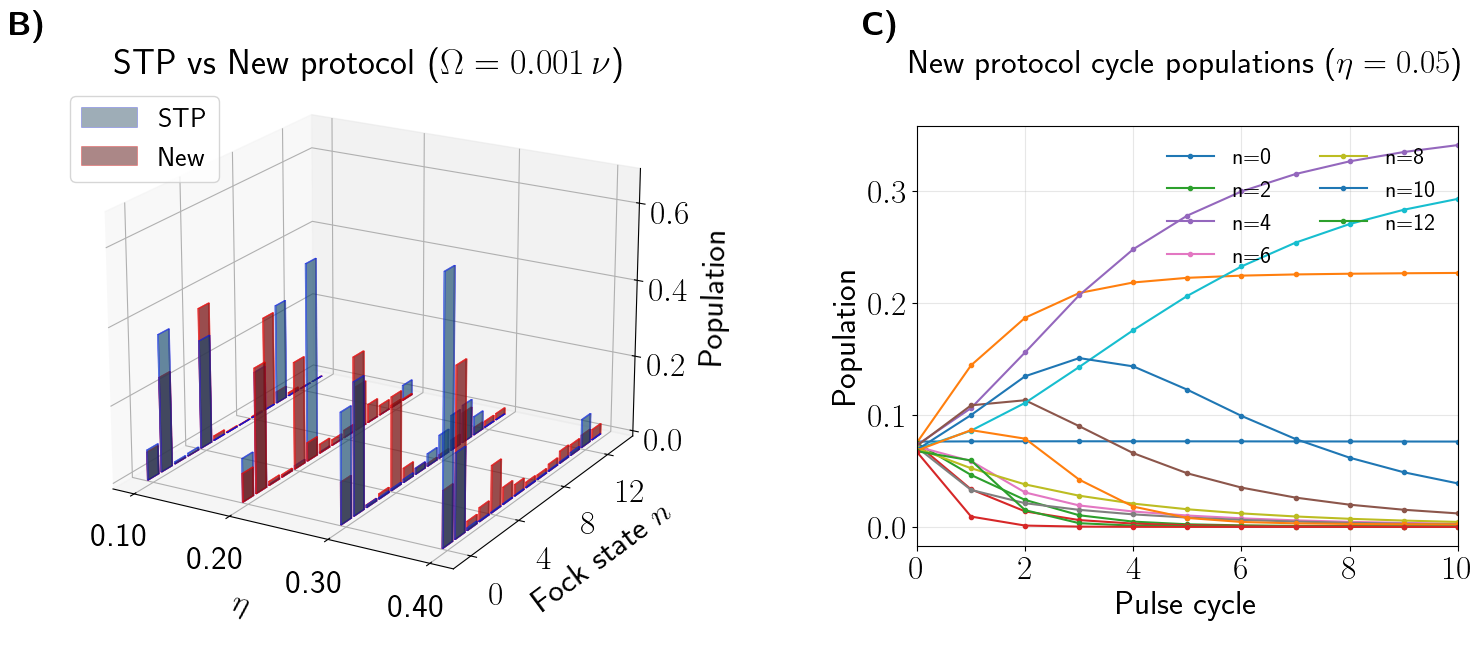

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from qutip import *

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 24,
    'axes.titlesize': 26,
    'axes.labelsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 20
})

# ── Shared parameters ──────────────────────────────────────────────
Delta_val = 0
RF_strength = 1
nu = 1.0
Omega_y = 100
n_thermal = 1
n0 = 1
gamma = 1000
kT = 1
beta = 0.01    # Inverse temperature
N = 14
num_pulses = 30
eta = 0.05
n_show = 14  # Only show first n_show Fock states for clarity


# ── Helper: build operators ────────────────────────────────────────
def build_operators(N, eta):
    a = destroy(N); a_dag = a.dag(); xop = a + a_dag
    sz = sigmaz(); s_plus = sigmap(); s_minus = sigmam()
    s_y = sigmay(); s_x = sigmax()
    s_z_full     = tensor(sz, qeye(N))
    s_plus_full  = tensor(s_plus, qeye(N))
    s_minus_full = tensor(s_minus, qeye(N))
    s_y_full     = tensor(s_y, qeye(N))
    s_x_full     = tensor(s_x, qeye(N))
    a_full       = tensor(qeye(2), a)
    a_dag_full   = tensor(qeye(2), a_dag)
    D_op         = tensor(qeye(2), displace(N, 1j * eta))
    return (a, a_dag, xop,
            s_z_full, s_plus_full, s_minus_full,
            s_y_full, s_x_full,
            a_full, a_dag_full, D_op)


# ── Helper: build collapse operators ───────────────────────────────
def build_c_ops(eta, xop, s_minus_full, gamma, N):
    cosmax = 100
    cosal = np.arange(-cosmax, cosmax + 1) / cosmax
    W = 3 * (cosal**2 + 1) / 4 / (2 * cosmax)
    W = W / W.sum()
    G = gamma / 2
    c_ops = []
    for i, c in enumerate(cosal):
        U_mot = (1j * c * eta * xop).expm()
        U_full = tensor(qeye(2), U_mot)
        c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))
    c_ops.append(np.sqrt(gamma) * s_minus_full)
    return c_ops


# ── Old protocol propagator ───────────────────────────────────────
def old_protocol_propagator(Omega, eta, N, gamma, nu, kT):
    (a, a_dag, xop, s_z_full, s_plus_full, s_minus_full,
     s_y_full, s_x_full, a_full, a_dag_full, D_op) = build_operators(N, eta)
    Delta = 1
    tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))
    H_pulse = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
            0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
    H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

    c_ops = build_c_ops(eta, xop, s_minus_full, gamma, N)
    G = gamma / 2; tg = 2 / G
    prop_pulse = (liouvillian(H_pulse, []) * tau).expm()
    prop_diss  = (liouvillian(H_diss, c_ops) * tg).expm()
    return prop_diss * prop_pulse


# ── New protocol propagator ───────────────────────────────────────
def new_protocol_propagator(Omega, eta, N, gamma, nu, Delta, kT, Omega_y):
    (a, a_dag, xop, s_z_full, s_plus_full, s_minus_full,
     s_y_full, s_x_full, a_full, a_dag_full, D_op) = build_operators(N, eta)
    tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))
    H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

    H_rf = (RF_strength / 2) * (a_full + a_dag_full)
    rf_duration = eta / RF_strength
    L_rf = liouvillian(H_rf, [])
    prop_rf      = (L_rf * rf_duration).expm()
    prop_rf_undo = (-L_rf * rf_duration).expm()

    H_y = (0.5 * Delta * s_z_full + nu * a_dag_full * a_full +
           0.5 * Omega_y * (-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag()))
    y_duration = np.pi / (2 * Omega_y)
    prop_y      = (liouvillian(H_y, []) * y_duration).expm()
    prop_y_undo = (liouvillian(-H_y, []) * y_duration).expm()

    H_x = 0.5 * Delta * s_x_full + nu * a_dag_full * a_full + 0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
    prop_x = (liouvillian(H_x, []) * tau).expm()

    c_ops = build_c_ops(eta, xop, s_minus_full, gamma, N)
    G = gamma / 2; tg = 2 / G
    prop_diss = (liouvillian(H_diss, c_ops) * tg).expm()
    return prop_diss * prop_rf_undo * prop_y_undo * prop_x * prop_y * prop_rf


# ── Run cooling simulation ────────────────────────────────────────
def run_trapping(prop_cycle, N, nu, kT, beta, num_pulses):
    a = destroy(N); a_dag = a.dag()
    thermal_state = (-beta * nu * a_dag * a / kT).expm()
    thermal_state = thermal_state / thermal_state.tr()
    ground_state  = basis(2, 1)
    initial_state = tensor(ground_state * ground_state.dag(), thermal_state)
    rho_vec = operator_to_vector(initial_state)
    current = rho_vec
    for k in range(num_pulses):
        current = prop_cycle * current
    final_pops = vector_to_operator(current).ptrace(1).diag().real
    return np.array(final_pops).flatten()


# ── Collect data for Panel A (sweep η at fixed Ω) ──────────────────
Omega_fixed_A = 0.001 * nu  # Very low Rabi frequency to highlight differences
Omega_new = nu
eta_values_A = [0.1, 0.2, 0.3, 0.4]
results_old_A = {}
results_new_A = {}

for eta_val in eta_values_A:
    print(f"Panel A: η = {eta_val}")
    prop_old = old_protocol_propagator(Omega_fixed_A, eta_val, N, gamma, nu, kT)
    prop_new = new_protocol_propagator(Omega_new, eta_val, N, gamma, nu, Delta_val, kT, Omega_y)
    results_old_A[eta_val] = run_trapping(prop_old, N, nu, kT, beta, num_pulses)
    results_new_A[eta_val] = run_trapping(prop_new, N, nu, kT, beta, num_pulses)
    print(f"  Old n̄={np.dot(np.arange(N), results_old_A[eta_val]):.4f},  "
          f"New n̄={np.dot(np.arange(N), results_new_A[eta_val]):.4f}")


# ── Panel C data: cycle-by-cycle populations (NEW protocol) ───────
Omega_cycle_C = nu
eta_cycle_C = 0.05
num_cycles_C = 10

print(f"Panel C: cycle populations (NEW) — η = {eta_cycle_C}, Ω = {Omega_cycle_C} ...")
prop_cycle_C = new_protocol_propagator(Omega_cycle_C, eta_cycle_C, N, gamma, nu, Delta_val, kT, Omega_y)

a = destroy(N); a_dag = a.dag()
thermal_state = (-beta * nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state  = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

occupancies_C = np.zeros((num_cycles_C + 1, N))
rho_vec = operator_to_vector(initial_state)
occupancies_C[0, :] = vector_to_operator(rho_vec).ptrace(1).diag().real

current_rho_vec = rho_vec
for k in range(1, num_cycles_C + 1):
    current_rho_vec = prop_cycle_C * current_rho_vec
    occupancies_C[k, :] = vector_to_operator(current_rho_vec).ptrace(1).diag().real

cycles_C = np.arange(num_cycles_C + 1)


# ╔══════════════════════════════════════════════════════════════════╗
# ║  3D Bar Figure — 2D slices separated along the eta axis         ║
# ╚══════════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(19, 7.5))
gs_panels = fig.add_gridspec(1, 2, width_ratios=[1.15, 0.85])

bar_width = 0.8   # width along fock-state axis
bar_depth = 0.02  # very thin along Omega axis → looks 2D
spacing = 1.6     # spacing between Omega slices
n_fock = np.arange(n_show)

# ── Panel B: Old (blue) vs New (orange) superimposed ──────────────
ax1 = fig.add_subplot(gs_panels[0, 0], projection='3d')

for slice_idx, eta_val in enumerate(eta_values_A):
    x_centre = slice_idx * spacing
    z_old = results_old_A[eta_val][:n_show]
    z_new = results_new_A[eta_val][:n_show]

    # Draw old (blue) first so it sits behind
    ax1.bar3d(np.full(n_show, x_centre - bar_depth / 2),
              n_fock - bar_width / 2, np.zeros(n_show),
              bar_depth, bar_width, z_old,
              color='tab:blue', alpha=0.4, edgecolor='b', linewidth=0.4,
              label='STP' if slice_idx == 0 else '', zsort='average')
    # Draw new (red) on top
    ax1.bar3d(np.full(n_show, x_centre - bar_depth / 2),
              n_fock - bar_width / 2, np.zeros(n_show),
              bar_depth, bar_width, z_new,
              color='tab:red', alpha=0.5, edgecolor='r', linewidth=0.4,
              label='New' if slice_idx == 0 else '', zsort='average')

ax1.set_xticks([i * spacing for i in range(len(eta_values_A))])
ax1.set_xticklabels([f'{e:.2f}' for e in eta_values_A])
ax1.set_xlabel(r'$\eta$', labelpad=20)
ax1.set_ylabel('Fock state $n$', labelpad=16)
ax1.set_yticks(np.arange(0, n_show, 4))
ax1.set_zlabel('Population', labelpad=14)
ax1.view_init(elev=20, azim=-60)
ax1.tick_params(axis='x', pad=8)
ax1.tick_params(axis='y', pad=8)
ax1.tick_params(axis='z', pad=6)
ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 0.90), borderaxespad=0.0)

# ── Panel C: cycle-by-cycle motional populations (NEW protocol) ───
ax2 = fig.add_subplot(gs_panels[0, 1])

for n in range(N):
    label = f'n={n}' if (n % 2 == 0) else '_nolegend_'
    ax2.plot(cycles_C, occupancies_C[:, n], '.-', label=label)

ax2.set_xlabel('Pulse cycle')
ax2.set_ylabel('Population')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, num_cycles_C)
ax2.tick_params(axis='both')
ax2.legend(loc='upper right', frameon=False, fontsize=17, ncol=2)

# Layout note: for 3D axes, bbox_inches='tight' can clip z-labels.
# Use explicit subplot margins + default bbox instead.
fig.subplots_adjust(left=0.09, right=0.995, bottom=0.10, top=0.90, wspace=0.0)

# Even with wspace=0, 3D axes often keep a big visual gap (labels/ticks).
# Squeeze the axes positions to enforce a small inter-panel gap.
fig.canvas.draw()
pos1 = ax1.get_position()
pos2 = ax2.get_position()
current_gap = pos2.x0 - pos1.x1
target_gap = 0.08
if current_gap > target_gap:
    delta = (current_gap - target_gap) / 2
    ax1.set_position([pos1.x0 + delta, pos1.y0, pos1.width, pos1.height])
    ax2.set_position([pos2.x0 - delta, pos2.y0, pos2.width, pos2.height])

# Make the 2D panel visually smaller (leave some whitespace around it)
pos2 = ax2.get_position()
shrink_w = 0.74
shrink_h = 0.7
ax2.set_position([
    pos2.x0 + pos2.width * (1 - shrink_w) / 2,
    pos2.y0 + pos2.height * (1 - shrink_h) / 2,
    pos2.width * shrink_w,
    pos2.height * shrink_h,
])

# Align Panel B/C labels and titles to the same height
fig.canvas.draw()
pos1 = ax1.get_position()
pos2 = ax2.get_position()
y_top = max(pos1.y1, pos2.y1)
y_label_fig = min(0.985, y_top + 0.035)
y_title_fig = min(0.965, y_label_fig - 0.050)
yB_label = (y_label_fig - pos1.y0) / pos1.height
yC_label = (y_label_fig - pos2.y0) / pos2.height
yB_title = (y_title_fig - pos1.y0) / pos1.height
yC_title = (y_title_fig - pos2.y0) / pos2.height
ax1.text2D(-0.10, yB_label, r'\textbf{B)}', transform=ax1.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')
ax2.text(-0.10, yC_label, r'\textbf{C)}', transform=ax2.transAxes, fontsize=24, fontweight='bold', va='top', ha='left')
ax1.text2D(0.5, yB_title, rf'STP vs New protocol ($\Omega={Omega_fixed_A}\,\nu$)', transform=ax1.transAxes, fontsize=plt.rcParams['axes.titlesize'], fontweight='bold', va='top', ha='center')
ax2.text(0.5, yC_title, rf'New protocol cycle populations ($\eta={eta_cycle_C}$)', transform=ax2.transAxes, fontweight='bold', va='top', ha='center')

# Save combined figure (PDF + PNG)
fig.savefig('figure_3.pdf', format='pdf', dpi=600)
fig.savefig('figure_3.png', format='png', dpi=600)

# Save each panel as its own PNG using axis-specific bounding boxes
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
panel_targets = [
    (ax1, 'figure_3_panel_left.png'),
    (ax2, 'figure_3_panel_right.png')
]
for axis, filename in panel_targets:
    # Extra expansion helps include 3D axis labels reliably
    bbox = axis.get_tightbbox(renderer).expanded(1.10, 1.12)
    bbox = bbox.transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(filename, format='png', dpi=600, bbox_inches=bbox)

plt.show()

### Trace distance between analytical old states 

Computing trace distance vs Ω for η=0.020 ...
Computing trace distance vs Ω for η=0.050 ...
Computing trace distance vs Ω for η=0.080 ...
Computing trace distance for η=0.020 ...
Computing trace distance for η=0.045 ...
Computing trace distance for η=0.071 ...
Computing trace distance for η=0.096 ...
Computing trace distance for η=0.121 ...
Computing trace distance for η=0.147 ...
Computing trace distance for η=0.172 ...
Computing trace distance for η=0.197 ...
Computing trace distance for η=0.223 ...
Computing trace distance for η=0.248 ...
Computing trace distance for η=0.273 ...
Computing trace distance for η=0.299 ...
Computing trace distance for η=0.324 ...
Computing trace distance for η=0.349 ...
Computing trace distance for η=0.375 ...
Computing trace distance for η=0.400 ...


C:\Users\Gonzalo\AppData\Local\Temp\ipykernel_17620\957703022.py:367: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 1.1))


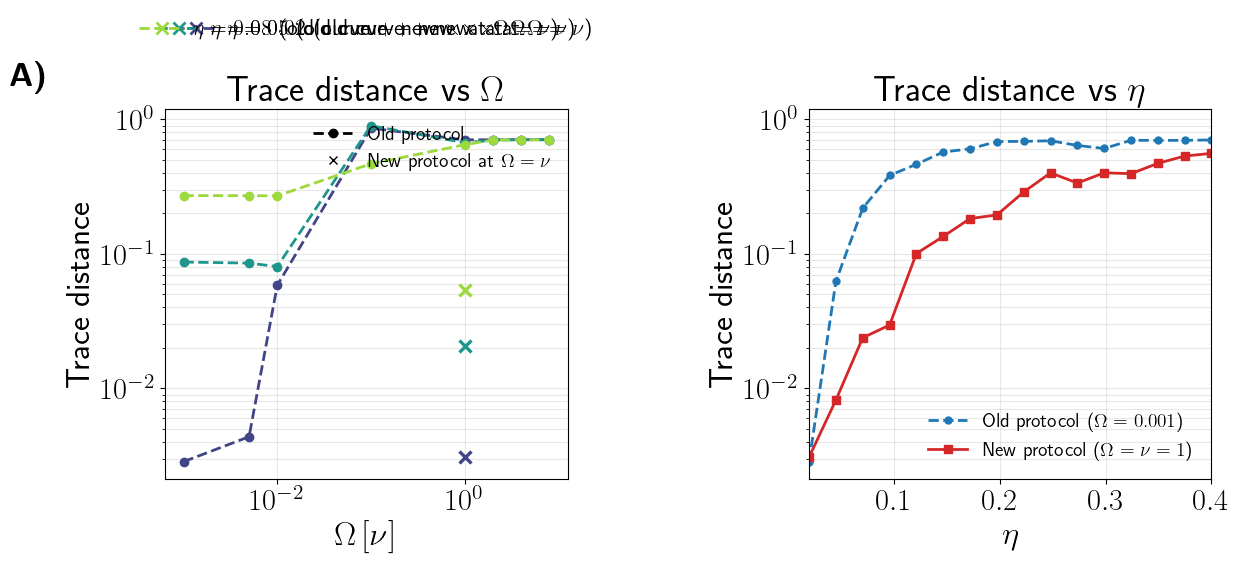

Omega values: [1.e-03 5.e-03 1.e-02 1.e-01 1.e+00 2.e+00 4.e+00 8.e+00]
η-sweep NEW uses Ω≈ν.
η-sweep OLD uses Ω=0.001 (=ν/10).
η sweep: [0.020, 0.400] with 16 points.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerTuple
from qutip import *

# ==========================================================
# Trace distance to ideal trapped state
# Panel A layout:
#   - Left: Trace distance vs Ω for OLD (dashed) and NEW (solid) protocols, for multiple η
#   - Right: Trace distance vs η with NEW at Ω≈1.0 and OLD at Ω=ν/10, sweeping η up to 0.4
# ==========================================================

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 18,
    'axes.titlesize': 26,
    'axes.labelsize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 18
})

# --- Shared parameters ---
N = 14
n0 = 1
eta_values = [0.02, 0.05, 0.08]
eta = eta_values[1]  # keep reference value for downstream cells
nu = 1.0
gamma = 1000
kT = 1.0
beta = 0.01
num_pulses = 30
RF_strength = 1
Omega_y = 1000
Delta_old = 1.0   # old STP settings
Delta_new = 0.0   # new-sequence settings
Delta = Delta_new  # used in H_x in the new sequence
Omega_values = np.array([0.001, 0.005, 0.01, 0.1, 1.0, 2.0, 4.0, 8.0])
n_op = num(N)
fock_projectors = [fock_dm(N, n) for n in range(N)]

# --- Operator builder ---
def build_ops(N, eta_val):
    a = destroy(N)
    a_dag = a.dag()
    xop = a + a_dag

    sz = sigmaz()
    s_plus = sigmap()
    s_minus = sigmam()
    s_x = sigmax()
    s_y = sigmay()

    s_z_full = tensor(sz, qeye(N))
    s_plus_full = tensor(s_plus, qeye(N))
    s_minus_full = tensor(s_minus, qeye(N))
    s_x_full = tensor(s_x, qeye(N))
    s_y_full = tensor(s_y, qeye(N))
    a_full = tensor(qeye(2), a)
    a_dag_full = tensor(qeye(2), a_dag)
    D_op = tensor(qeye(2), displace(N, 1j * eta_val))

    return {
        'a': a, 'a_dag': a_dag, 'xop': xop,
        's_z_full': s_z_full, 's_plus_full': s_plus_full, 's_minus_full': s_minus_full,
        's_x_full': s_x_full, 's_y_full': s_y_full,
        'a_full': a_full, 'a_dag_full': a_dag_full,
        'D_op': D_op
    }

# --- Collapse operators with recoil ---
def build_c_ops(eta_val, xop, s_minus_full, gamma):
    cosmax = 100
    cosal = np.arange(-cosmax, cosmax + 1) / cosmax
    W = 3 * (cosal**2 + 1) / 4 / (2 * cosmax)
    W = W / np.sum(W)

    G = gamma / 2
    c_ops = []
    for i, c in enumerate(cosal):
        U_mot = (1j * c * eta_val * xop).expm()
        U_full = tensor(qeye(2), U_mot)
        c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

    c_ops.append(np.sqrt(gamma) * s_minus_full)
    tg = 2 / G
    return c_ops, tg

# --- Thermal initial state ---
def build_thermal_state(N, nu, beta, kT):
    a_th = destroy(N)
    a_th_dag = a_th.dag()
    rho_th = (-beta * nu * a_th_dag * a_th / kT).expm()
    return rho_th / rho_th.tr()

# --- Initial and ideal trapped distributions ---
thermal_state_ref = build_thermal_state(N, nu, beta, kT)
initial_probs = np.real(np.array(thermal_state_ref.diag())).flatten()

# Analytical ideal trapped distribution via trap bins
ideal_probs = np.zeros(N)
m = 0
while True:
    trap_idx = n0 * m**2
    next_trap_idx = n0 * (m + 1)**2
    if trap_idx >= N:
        break
    start_n = trap_idx
    end_n = min(next_trap_idx, N)
    if start_n < N:
        ideal_probs[trap_idx] = np.sum(initial_probs[start_n:end_n])
    m += 1

# --- Final motional populations for each protocol ---
def final_pops_old_stp(Omega, eta_val):
    ops = build_ops(N, eta_val)
    xop = ops['xop']
    s_z_full = ops['s_z_full']
    s_plus_full = ops['s_plus_full']
    s_minus_full = ops['s_minus_full']
    a_full = ops['a_full']
    a_dag_full = ops['a_dag_full']
    D_op = ops['D_op']

    tau = 2 * np.pi / (eta_val * Omega * np.sqrt(n0))
    H_pulse = 0.5 * Delta_old * s_z_full + nu * a_dag_full * a_full + \
              0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
    H_diss = 0.5 * Delta_old * s_z_full + nu * a_dag_full * a_full

    c_ops, tg = build_c_ops(eta_val, xop, s_minus_full, gamma)

    prop_pulse = (liouvillian(H_pulse, []) * tau).expm()
    prop_diss = (liouvillian(H_diss, c_ops) * tg).expm()
    prop_cycle = prop_diss * prop_pulse

    thermal_state = build_thermal_state(N, nu, beta, kT)
    spin_g = basis(2, 1)
    init_state = tensor(spin_g * spin_g.dag(), thermal_state)

    rho_vec = operator_to_vector(init_state)
    for _ in range(num_pulses):
        rho_vec = prop_cycle * rho_vec

    rho_final = vector_to_operator(rho_vec)
    rho_motional = rho_final.ptrace(1)
    return np.real(np.array(expect(fock_projectors, rho_motional))).flatten()


def final_pops_new_sequence(Omega, eta_val):
    ops = build_ops(N, eta_val)
    xop = ops['xop']
    s_z_full = ops['s_z_full']
    s_plus_full = ops['s_plus_full']
    s_minus_full = ops['s_minus_full']
    s_x_full = ops['s_x_full']
    a_full = ops['a_full']
    a_dag_full = ops['a_dag_full']
    D_op = ops['D_op']

    tau = 2 * np.pi / (eta_val * Omega * np.sqrt(n0))
    H_diss = 0.5 * Delta_new * s_z_full + nu * a_dag_full * a_full

    # RF pulse and undo
    H_rf = 0.5 * RF_strength * (a_full + a_dag_full)
    rf_duration = eta_val / RF_strength
    L_rf = liouvillian(H_rf, [])
    prop_rf = (L_rf * rf_duration).expm()
    prop_rf_undo = (-L_rf * rf_duration).expm()

    # Y(pi/2) pulse and undo
    H_y = 0.5 * Delta_new * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega_y * (-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
    y_duration = np.pi / (2 * Omega_y)
    prop_y = (liouvillian(H_y, []) * y_duration).expm()
    prop_y_undo = (liouvillian(-H_y, []) * y_duration).expm()

    # X(tau) pulse
    H_x = 0.5 * Delta * s_x_full + nu * a_dag_full * a_full + 0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
    prop_x = (liouvillian(H_x, []) * tau).expm()

    c_ops, tg = build_c_ops(eta_val, xop, s_minus_full, gamma)
    prop_diss = (liouvillian(H_diss, c_ops) * tg).expm()

    prop_cycle = prop_diss * prop_rf_undo * prop_y_undo * prop_x * prop_y * prop_rf

    thermal_state = build_thermal_state(N, nu, beta, kT)
    spin_g = basis(2, 1)
    init_state = tensor(spin_g * spin_g.dag(), thermal_state)

    rho_vec = operator_to_vector(init_state)
    for _ in range(num_pulses):
        rho_vec = prop_cycle * rho_vec

    rho_final = vector_to_operator(rho_vec)
    rho_motional = rho_final.ptrace(1)
    return np.real(np.array(expect(fock_projectors, rho_motional))).flatten()


def to_diag_dm(probs):
    probs = np.real(np.array(probs, dtype=float)).flatten()
    probs = np.clip(probs, 0.0, None)
    probs = probs / np.sum(probs)
    return Qobj(np.diag(probs), dims=[[N], [N]])

rho_ideal = to_diag_dm(ideal_probs)

# --- Precompute trace distances vs Ω for a small set of η (used in left subplot) ---
# Compute OLD and NEW for all Ω so both protocols can be compared at the same η values.
trace_results = {}
for eta_val in eta_values:
    print(f"Computing trace distance vs Ω for η={eta_val:.3f} ...")
    td_old = []
    td_new = []
    for i, Om in enumerate(Omega_values):
        p_old = final_pops_old_stp(Om, eta_val)
        rho_old = to_diag_dm(p_old)
        td_old.append(float(tracedist(rho_old, rho_ideal)))
        p_new = final_pops_new_sequence(Om, eta_val)
        rho_new = to_diag_dm(p_new)
        td_new.append(float(tracedist(rho_new, rho_ideal)))

    trace_results[eta_val] = {
        'old': np.array(td_old, dtype=float),
        'new': np.array(td_new, dtype=float)
    }

# --- Compute trace distance vs η at fixed Ω (used in right subplot) ---
# NEW protocol: Ω ≈ 1.0 (nearest value from Omega_values)
omega_used_new = nu
# OLD protocol: Ω = ν/10 (i.e. 0.1 in units of ν)
omega_used_old = float(nu / 1000)
eta_sweep = np.linspace(0.02, 0.4, 16)

td_new_sweep = []
td_old_sweep = []
for eta_val in eta_sweep:
    print(f"Computing trace distance for η={eta_val:.3f} ...")
    eta_val = float(eta_val)
    p_new = final_pops_new_sequence(omega_used_new, eta_val)
    p_old = final_pops_old_stp(omega_used_old, eta_val)
    rho_new = to_diag_dm(p_new)
    rho_old = to_diag_dm(p_old)
    td_new_sweep.append(float(tracedist(rho_new, rho_ideal)))
    td_old_sweep.append(float(tracedist(rho_old, rho_ideal)))
td_new_sweep = np.array(td_new_sweep, dtype=float)
td_old_sweep = np.array(td_old_sweep, dtype=float)

# expose for downstream cells (vector-PDF builder)
eta_sweep_values = eta_sweep
td_new_vs_eta = td_new_sweep
td_old_vs_eta = td_old_sweep
omega_used_for_eta_sweep = omega_used_new
omega_used_for_eta_sweep_old = omega_used_old

# --- Plot (Panel A) ---
# Use a shared y-axis so both panels have identical scaling.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True, gridspec_kw={'wspace': 0.60})
ax_left, ax_right = axes

# Colors (use same color per η for both protocols)
eta_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(eta_values)))

# Left: OLD curves vs Ω, NEW shown only as crosses at Ω=ν (ν=1)
omega_ref = 1.0
omega_arr = np.asarray(Omega_values, dtype=float)
idx_omega_ref = int(np.argmin(np.abs(omega_arr - omega_ref)))
omega_marker = float(omega_arr[idx_omega_ref])
for c, eta_val in zip(eta_colors, eta_values):
    y_old = np.asarray(trace_results[eta_val]['old'], dtype=float)
    y_new = np.asarray(trace_results[eta_val]['new'], dtype=float)
    ax_left.plot(
        omega_arr,
        y_old,
        marker='o',
        linestyle='--',
        color=c,
        lw=2,
        ms=6,
    )
    ax_left.plot(
        [omega_marker],
        [float(y_new[idx_omega_ref])],
        marker='x',
        linestyle='None',
        color=c,
        ms=9,
        mew=2.4,
    )
ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.set_xlabel(r'$\Omega\,[\nu]$')
ax_left.set_ylabel(r'Trace distance')
ax_left.set_title(r'Trace distance vs $\Omega$')
ax_left.grid(True, which='both', alpha=0.3)

# Right: OLD and NEW vs b7 sweep at fixed a9
line_old_eta, = ax_right.plot(
    eta_sweep_values,
    td_old_vs_eta,
    marker='o',
    linestyle='--',
    color='tab:blue',
    lw=2,
    ms=5,
    label=fr'Old protocol ($\Omega={omega_used_old:g}$)',
 )
line_new_eta, = ax_right.plot(
    eta_sweep_values,
    td_new_vs_eta,
    marker='s',
    linestyle='-',
    color='tab:red',
    lw=2,
    ms=6,
    label=fr'New protocol ($\Omega=\nu=1$)',
 )
ax_right.set_xlabel(r'$\eta$')
ax_right.set_ylabel(r'Trace distance')
ax_right.set_title(r'Trace distance vs $\eta$')
ax_right.grid(True, which='both', alpha=0.3)
ax_right.set_xlim(float(eta_sweep_values.min()), float(eta_sweep_values.max()))
ax_right.set_yscale('log')
ax_right.tick_params(axis='y', which='both', labelleft=True)
ax_right.legend(loc='lower right', frameon=False, fontsize=14)

# Legends: protocol style (inside axes) + η color mapping (above)
style_legend = ax_left.legend(
    handles=[
        Line2D([0], [0], color='k', lw=2, marker='o', linestyle='--', label='Old protocol'),
        Line2D([0], [0], color='k', lw=0, marker='x', linestyle='None', label=r'New protocol at $\Omega=\nu$'),
    ],
    loc='upper right',
    frameon=False,
    fontsize=14,
 )
ax_left.add_artist(style_legend)
eta_legend_handles = [
    Line2D(
        [0], [0],
        color=c,
        lw=2,
        linestyle='--',
        marker='x',
        ms=8,
        mew=2.0,
        label=fr'$\eta={eta_val:.2f}$ (old curve + new $\times$ at $\Omega=\nu$)'
    )
    for c, eta_val in zip(eta_colors, eta_values)
]
ax_left.legend(
    handles=eta_legend_handles,
    labels=[h.get_label() for h in eta_legend_handles],
    loc='lower left',
    bbox_to_anchor=(0.0, 1.16, 1.0, 0.2),
    mode='expand',
    ncol=3,
    frameon=False,
    borderaxespad=0.0,
    handletextpad=0.4,
    fontsize=16,
 )

fig.text(0.01, 0.98, r'\textbf{A)}', transform=fig.transFigure,
         fontsize=24, fontweight='bold', va='top', ha='left')
fig.tight_layout(rect=(0, 0, 1, 1.1))

plt.savefig('figure_trace_distance.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.savefig('figure_trace_distance.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

print('Omega values:', Omega_values)
print(f'η-sweep NEW uses Ω≈ν.')
print(f'η-sweep OLD uses Ω={omega_used_old} (=ν/10).')
print(f'η sweep: [{eta_sweep_values.min():.3f}, {eta_sweep_values.max():.3f}] with {len(eta_sweep_values)} points.')

In [13]:
from pathlib import Path
# ── Vectorized PDF version (for LaTeX) ─────────────────────────────
# Single-column layout: only the two trace-distance panels (A and B).
# Rebuilds the plots from the existing in-memory data (run the Trace
# distance cell first). The former 3D-bar and cycle-population panels
# were removed from the manuscript figure.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

required = [
    'Omega_values', 'eta_values', 'trace_results',
    'eta_sweep_values', 'td_new_vs_eta', 'td_old_vs_eta',
    'omega_used_for_eta_sweep', 'omega_used_for_eta_sweep_old',
]
missing_vars = [name for name in required if name not in globals()]
if missing_vars:
    raise RuntimeError(
        'Missing data needed for vector PDF: ' + ', '.join(missing_vars) +
        ' (Run the Trace distance cell first.)'
    )

# Style matched to the other single-column manuscript figures
plt.rcParams.update({
    'text.usetex': False, 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 11, 'legend.fontsize': 9.5, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'lines.linewidth': 1.4, 'lines.markersize': 4,
    'figure.dpi': 200, 'savefig.bbox': 'tight',
})

fig, (a1, a2) = plt.subplots(2, 1, figsize=(3.6, 5.8))

# Panel A: old protocol (dashed) vs Omega; new protocol as crosses at Omega=nu
eta_plot_values = sorted([float(k) for k in trace_results.keys()])
eta_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(eta_plot_values)))
omega_arr = np.asarray(Omega_values, dtype=float)
idx_ref = int(np.argmin(np.abs(omega_arr - 1.0)))
for c, eta_val in zip(eta_colors, eta_plot_values):
    y_old = np.asarray(trace_results[eta_val]['old'], dtype=float)
    y_new = np.asarray(trace_results[eta_val]['new'], dtype=float)
    a1.plot(omega_arr, y_old, marker='o', linestyle='--', color=c, ms=4,
            label=rf'$\eta={eta_val:.2f}$')
    a1.plot([omega_arr[idx_ref]], [y_new[idx_ref]], marker='x',
            linestyle='None', color=c, ms=8, mew=2.0)
a1.set_xscale('log'); a1.set_yscale('log')
a1.set_xlabel(r'$\Omega$ $[\nu]$')
a1.set_ylabel('trace distance to ideal trap')
a1.grid(True, which='both', alpha=0.3)
a1.set_ylim(8e-4, 8)
leg_eta = a1.legend(loc='upper left', frameon=False, ncol=3,
                    columnspacing=0.7, handlelength=1.5, handletextpad=0.4)
a1.add_artist(leg_eta)
a1.legend(handles=[
    Line2D([0], [0], color='k', lw=1.4, linestyle='--', marker='o', ms=4,
           label='old protocol'),
    Line2D([0], [0], color='k', lw=0, marker='x', ms=7, mew=2.0,
           label=r'new protocol at $\Omega=\nu$')],
    loc='lower left', frameon=False)
a1.text(0.0, 1.02, 'A)', transform=a1.transAxes, va='bottom', fontweight='bold')

# Panel B: eta sweep at fixed Omega
eta_sweep_arr = np.asarray(eta_sweep_values, dtype=float)
a2.plot(eta_sweep_arr, np.asarray(td_old_vs_eta, dtype=float), marker='o',
        linestyle='--', color='tab:blue', ms=4,
        label=rf'old protocol ($\Omega={float(omega_used_for_eta_sweep_old):g}\nu$)')
a2.plot(eta_sweep_arr, np.asarray(td_new_vs_eta, dtype=float), marker='s',
        linestyle='-', color='tab:red', ms=4,
        label=r'new protocol ($\Omega=\nu$)')
a2.set_xlabel(r'Lamb-Dicke parameter $\eta$')
a2.set_ylabel('trace distance to ideal trap')
a2.set_yscale('log'); a2.grid(True, which='both', alpha=0.3)
a2.set_xlim(float(eta_sweep_arr.min()), float(eta_sweep_arr.max()))
a2.legend(loc='lower right', frameon=False)
a2.text(0.0, 1.02, 'B)', transform=a2.transAxes, va='bottom', fontweight='bold')

fig.tight_layout()
pdf_out = Path('figures/figure_3_plus_trace.pdf')
pdf_out.parent.mkdir(exist_ok=True)
fig.savefig(pdf_out, format='pdf', bbox_inches='tight')
plt.close(fig)
print(f'Vector PDF saved to: {pdf_out.resolve()}')


Vector PDF saved to: C:\Users\Gonzalo\Downloads\QLearn\trapped_ions\fock_mixtures\figures\figure_3_plus_trace.pdf


### Figure 4

Omega=1 done — n_bar final=4.994
Omega=4 done — n_bar final=5.231


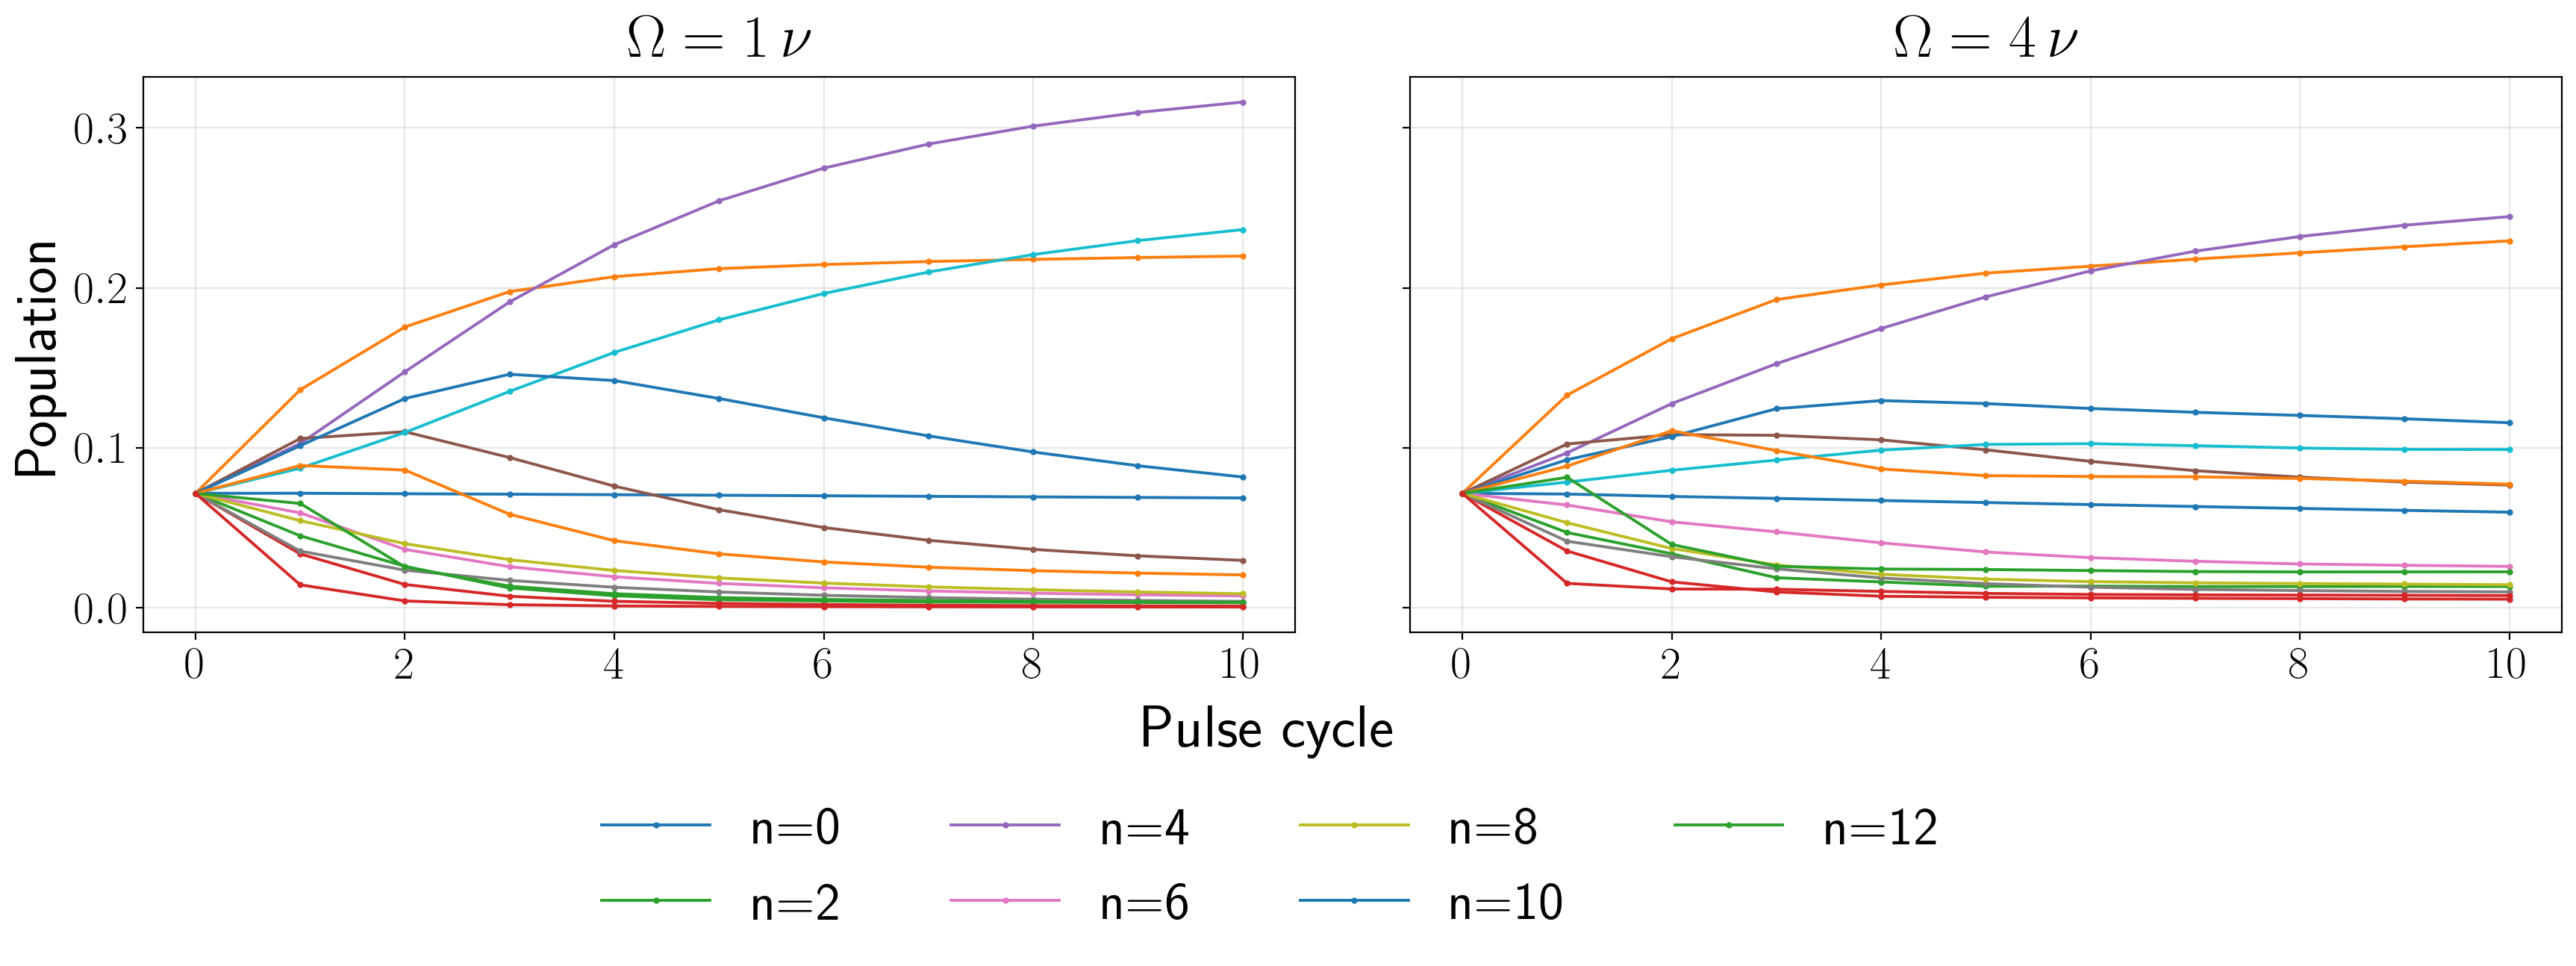

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Match the style used in the vector PDF figure above
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 24,
    'axes.titlesize': 29,
    'axes.labelsize': 28,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 26
})

# Define system parameters
Delta = 0
RF_strength = 1
nu = 1.0
eta = 0.05
Omega_y = 100
n_thermal = 1
n0 = 1
gamma = 1000
kT = 100
beta = 0.01  # Inverse temperature
N = 14
num_pulses = 10

Omega_values = [1, 4]

# Layout (shared legend below, so the plots keep full width)
subplot_left = 0.08
subplot_right = 0.98

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for idx, Omega in enumerate(Omega_values):
    tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))

    # QHO operators
    a = destroy(N)
    a_dag = a.dag()
    xop = a + a_dag

    # Spin operators
    sz = sigmaz()
    s_plus = sigmap()
    s_minus = sigmam()
    s_y = sigmay()
    s_x = sigmax()

    # Full size operators
    s_z_full = tensor(sz, qeye(N))
    s_plus_full = tensor(s_plus, qeye(N))
    s_minus_full = tensor(s_minus, qeye(N))
    s_y_full = tensor(s_y, qeye(N))
    a_full = tensor(qeye(2), a)
    a_dag_full = tensor(qeye(2), a_dag)
    s_x_full = tensor(s_x, qeye(N))

    D_op = tensor(qeye(2), displace(N, 1j * eta))

    H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

    # 1) RF dipolar pulse
    H_rf = (RF_strength / 2) * (a_full + a_dag_full)
    rf_duration = eta / RF_strength
    L_rf = liouvillian(H_rf, [])
    prop_rf = (L_rf * rf_duration).expm()
    prop_rf_undo = (-L_rf * rf_duration).expm()

    # 2) Y(π/2) pulse
    H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega_y * (-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
    y_duration = np.pi / (2 * Omega_y)
    L_y = liouvillian(H_y, [])
    prop_y = (L_y * y_duration).expm()
    L_y_undo = liouvillian(-H_y, [])
    prop_y_undo = (L_y_undo * y_duration).expm()

    # 3) X(τ) pulse
    H_x = 0.5 * nu * s_x_full + nu * a_dag_full * a_full + \
              0.5 * 1j * Omega * eta * s_z_full * (a_dag_full - a_full)
    L_x = liouvillian(H_x, [])
    prop_x = (L_x * tau).expm()

    # Collapse operators with recoil
    cosmax = 100
    cosal = np.arange(-cosmax, cosmax + 1) / cosmax
    W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
    W = W / np.sum(W)
    G = gamma / 2
    tg = 2 / G
    c_ops = []
    for i, c in enumerate(cosal):
        U_mot = (1j * c * eta * xop).expm()
        U_full = tensor(qeye(2), U_mot)
        c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))
    c_ops.append(np.sqrt(gamma) * s_minus_full)

    # Propagators
    L_diss = liouvillian(H_diss, c_ops)
    prop_diss = (L_diss * tg).expm()
    prop_cycle = prop_diss * prop_rf_undo * prop_y_undo * prop_x * prop_y * prop_rf

    # Initial state
    thermal_state = (-beta * nu * a_dag * a / kT).expm()
    thermal_state = thermal_state / thermal_state.tr()
    ground_state = basis(2, 1)
    initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

    occupancies = np.zeros((num_pulses + 1, N))
    rho_vec = operator_to_vector(initial_state)
    rho_mat = vector_to_operator(rho_vec)
    occupancies[0, :] = rho_mat.ptrace(1).diag().real

    current_rho_vec = rho_vec
    for k in range(1, num_pulses + 1):
        current_rho_vec = prop_cycle * current_rho_vec
        rho_mat = vector_to_operator(current_rho_vec)
        occupancies[k, :] = rho_mat.ptrace(1).diag().real

    # Plot populations vs pulse cycle
    ax = axes[idx]
    times_sim = np.arange(num_pulses + 1)
    for n in range(N):
        # Only label every 2nd motional state to keep the legend manageable
        label = f'n={n}' if (idx == 0 and (n % 2 == 0)) else '_nolegend_'
        ax.plot(times_sim, occupancies[:, n], '.-', label=label)

    ax.set_title(rf'$\Omega = {Omega}\,\nu$', fontweight='bold', pad=10)
    ax.tick_params(axis='both')
    ax.grid(True, alpha=0.3)

    print(f"Omega={Omega} done — n_bar final={np.dot(np.arange(N), occupancies[-1, :]):.3f}")

axes[0].set_ylabel('Population')
# Bring the shared x-label closer to the axes (and keep it above the legend)
fig.supxlabel('Pulse cycle', y=0.16)
# fig.suptitle('Cycle populations for the new protocol', fontweight='bold', y=1.10)

# One shared legend below the plots (pulled up closer)
handles, labels = axes[0].get_legend_handles_labels()
legend_ncol = min(4, max(1, len(labels)))
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.16),
    ncol=legend_ncol,
    frameon=False,
)

# Reduce bottom padding (now that xlabel/legend are closer)
plt.subplots_adjust(left=subplot_left, right=subplot_right, top=0.92, bottom=0.30, wspace=0.10)

plt.savefig('figure_4.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.savefig('figure_4.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

# Escaping eta dependence

eta=0.2, Y(π/2) pulse duration: 0.015707963267948967
eta=0.2, X(τ) pulse duration: 31.41592653589793


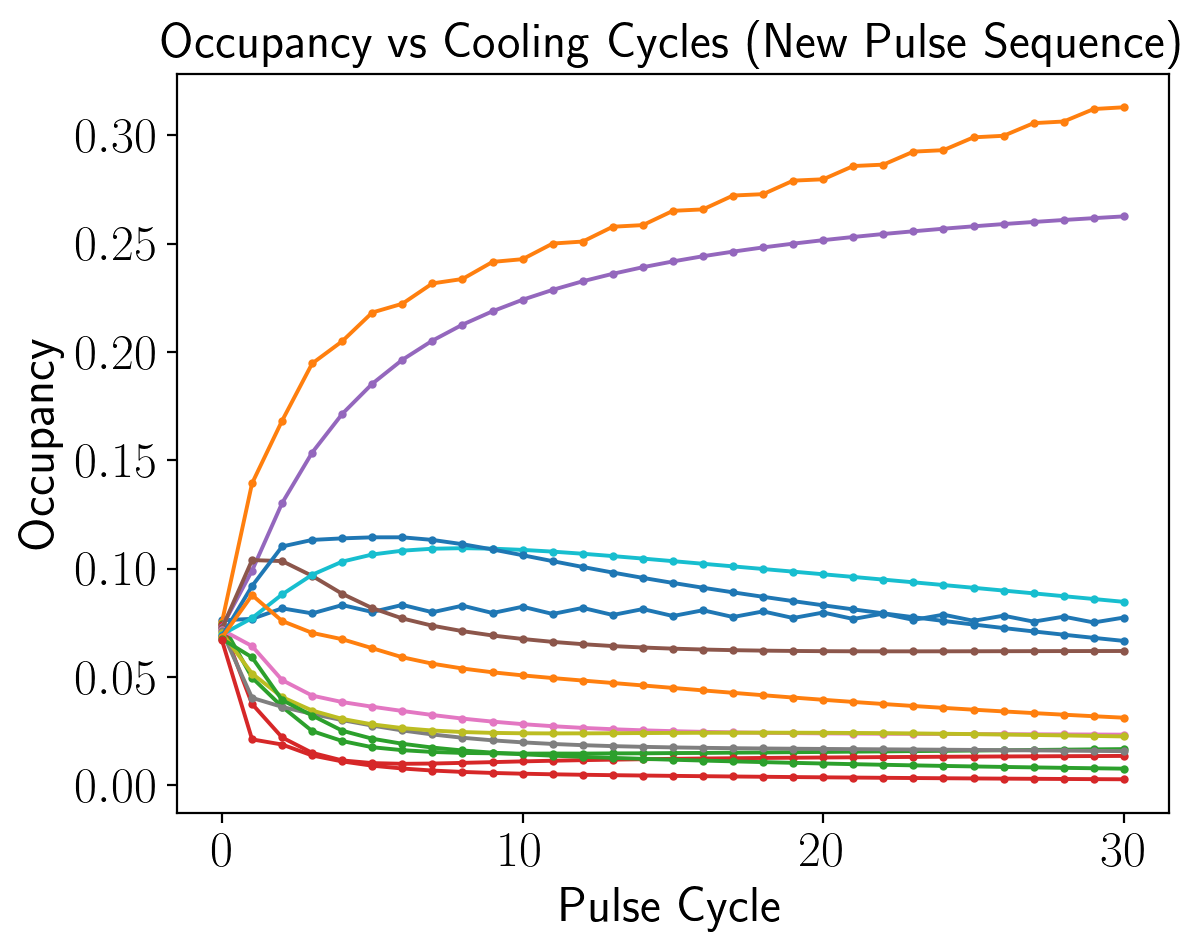

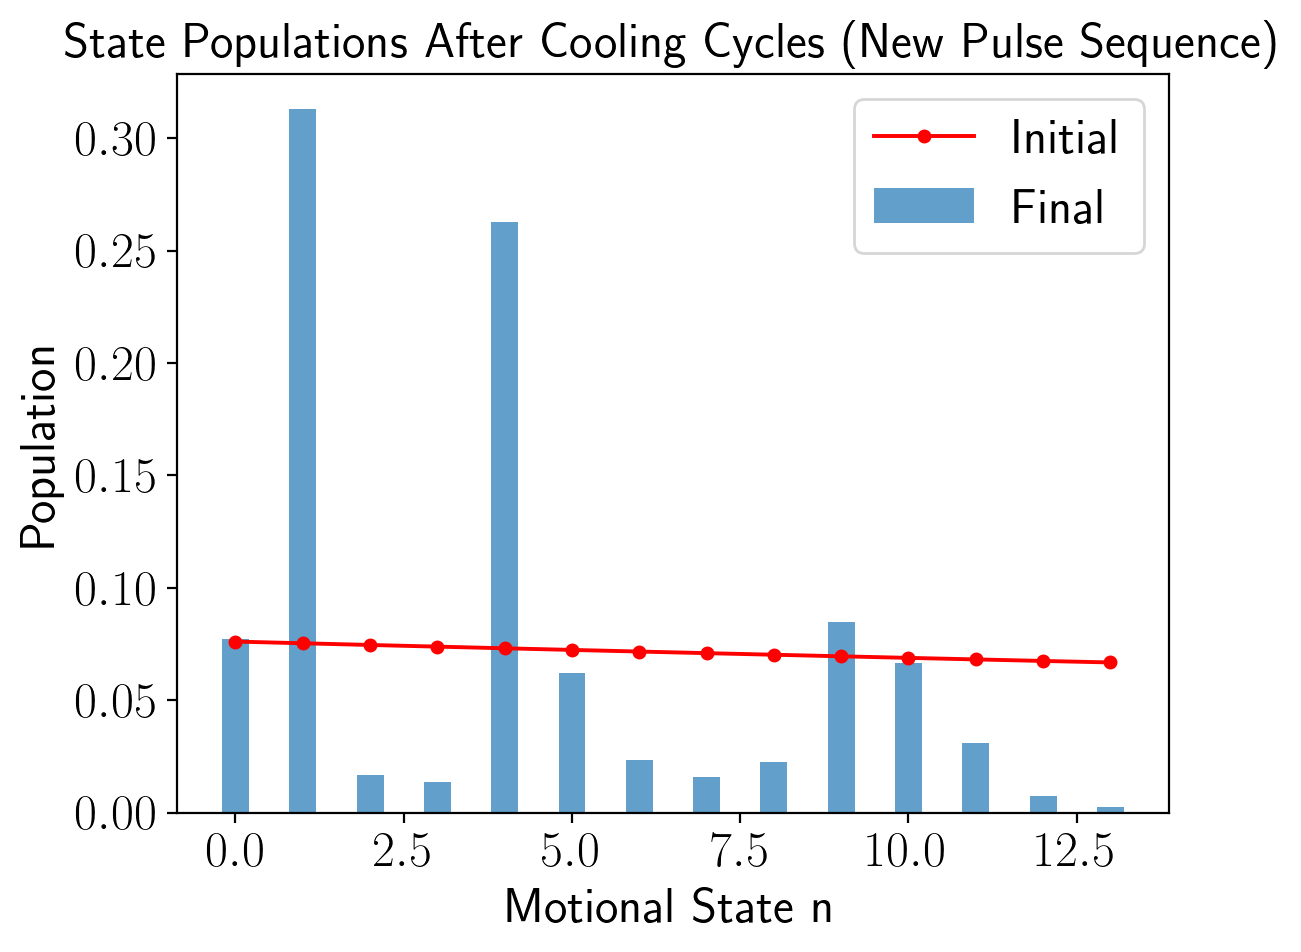

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 20,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Define system parameters
Delta = 0
eta = 0.2
RF_strength = 1
nu = 1.0
Omega = nu
Omega_y = 100
n_thermal = 1
n0 = 1
gamma = 1000
kT = 100
N = 14
num_pulses = 30

legend_handles = None
legend_labels = None


tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))

# QHO operators
a = destroy(N)
a_dag = a.dag()
xop = a + a_dag

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_x_full = tensor(s_x, qeye(N))

D_op = tensor(qeye(2), displace(N, 1j * eta))

H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# 1) RF dipolar pulse
# H_rf = (RF_strength / 2) * (a_full + a_dag_full)
# rf_duration = eta / RF_strength
# print(f"eta={eta}, RF pulse duration: {rf_duration}")
# L_rf = liouvillian(H_rf, [])
# prop_rf = (L_rf * rf_duration).expm()
# prop_rf_undo = (-L_rf * rf_duration).expm()

# 2) Y(π/2) pulse
# H_y = 0.5 * Omega_y * s_y_full
H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
        0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
y_duration = np.pi / (2 * Omega_y)
print(f"eta={eta}, Y(π/2) pulse duration: {y_duration}")
L_y = liouvillian(H_y, [])
prop_y = (L_y * y_duration).expm()
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * y_duration).expm()

# 3) X(τ) pulse
Delta_BS = -(eta * Omega)**2 / (4 * nu)
# H_x = 0.5 * nu * s_x_full + nu * a_dag_full * a_full + \
#           0.5 * 1j * Omega * eta * s_z_full * (a_dag_full - a_full)
# H_x = 0.5 * (Delta + Delta_BS) * s_x_full + nu * a_dag_full * a_full + 0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
H_x = 0.5 * (Delta) * s_x_full + nu * a_dag_full * a_full + 0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
print(f"eta={eta}, X(τ) pulse duration: {tau}")
L_x = liouvillian(H_x, [])
prop_x = (L_x * tau).expm()

# Collapse operators with recoil
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2
tg = 2 / G
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))
c_ops.append(np.sqrt(gamma) * s_minus_full)

# Propagators
L_diss = liouvillian(H_diss, c_ops)
prop_diss = (L_diss * tg).expm()
prop_cycle = prop_diss * prop_y_undo * prop_x * prop_y

# Initial state
thermal_state = (-nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real

times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles
# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
# plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies[0, :]
p_motional_final = occupancies[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial' , color='red')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()


eta=0.2, Y(π/2) pulse duration: 0.015707963267948967
Gaussian X pulse: peak Ω = 0.201ν, total duration = 31.416, M = 30 slices


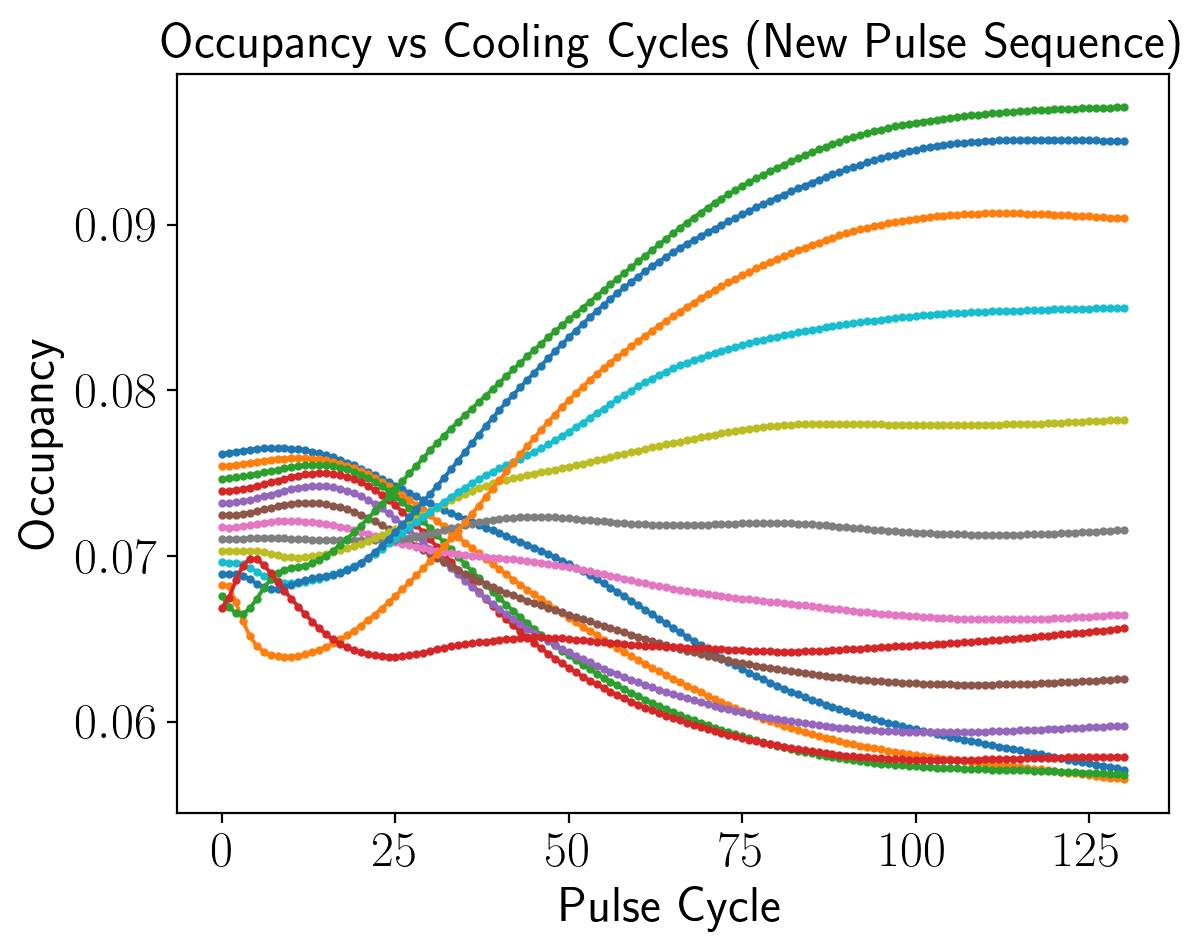

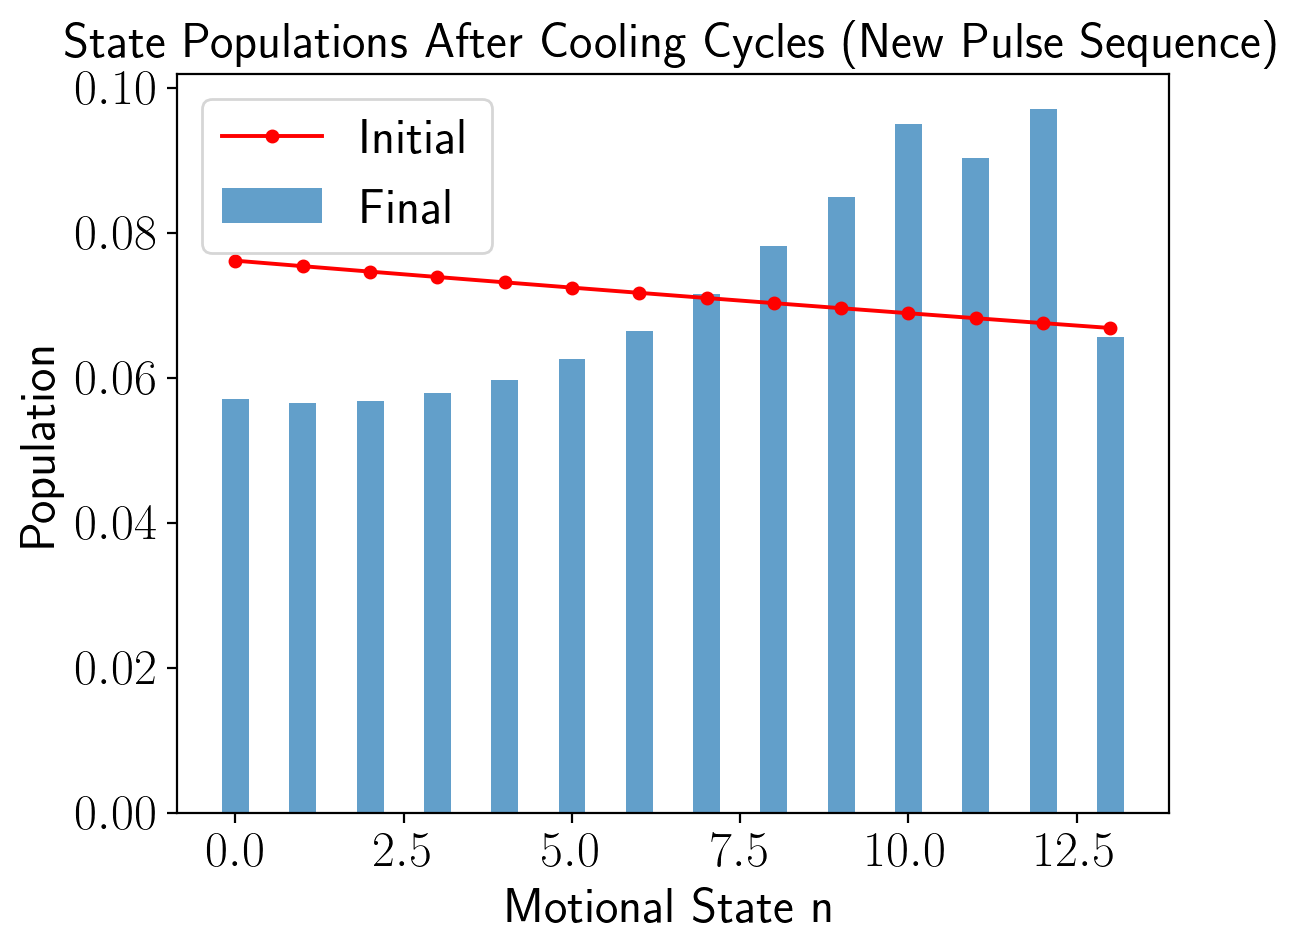

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 20,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Define system parameters
Delta = 0
eta = 0.2
RF_strength = 1
nu = 1.0
Omega = nu
Omega_y = 100
n_thermal = 1
n0 = 1
gamma = 1000
kT = 100
N = 14
num_pulses = 130

legend_handles = None
legend_labels = None


tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))

# QHO operators
a = destroy(N)
a_dag = a.dag()
xop = a + a_dag

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_x_full = tensor(s_x, qeye(N))

D_op = tensor(qeye(2), displace(N, 1j * eta))

H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# 2) Y(π/2) pulse
# H_y = 0.5 * Omega_y * s_y_full
H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
        0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
y_duration = np.pi / (2 * Omega_y)
print(f"eta={eta}, Y(π/2) pulse duration: {y_duration}")
L_y = liouvillian(H_y, [])
prop_y = (L_y * y_duration).expm()
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * y_duration).expm()


M = 30          # number of time slices — increase for accuracy, costs runtime
sigma_frac = 5  # pulse width as fraction of total duration (larger = smoother)

# Time slices centred on midpoints
t_mid = np.linspace(0, tau, M + 1)
dt = tau / M
t_centres = 0.5 * (t_mid[:-1] + t_mid[1:])

# Gaussian envelope, zero-centred on the pulse midpoint
t_centre = tau / 2
sigma_t = tau / sigma_frac
gauss_env = np.exp(-(t_centres - t_centre)**2 / (2 * sigma_t**2))

# Normalise so pulse area = π  (π-pulse condition)
gauss_area = np.sum(gauss_env) * dt
Omega_gauss = (np.pi / gauss_area) * gauss_env

print(f"Gaussian X pulse: peak Ω = {Omega_gauss.max():.3f}ν, "
      f"total duration = {tau:.3f}, M = {M} slices")

# Compose M propagators, one per time slice
id_super = to_super(qeye([2, N]))   # identity superoperator

prop_x_gauss = id_super
for m in range(M):
    Om = float(Omega_gauss[m])
    H_slice = (0.5 * Delta * s_x_full
               + nu * a_dag_full * a_full
               + 0.5 * Om * (s_plus_full * D_op + s_minus_full * D_op.dag()))
    L_slice = liouvillian(H_slice, [])
    prop_x_gauss = (L_slice * dt).expm() * prop_x_gauss

# Collapse operators with recoil
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2
tg = 2 / G
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))
c_ops.append(np.sqrt(gamma) * s_minus_full)

# Propagators
L_diss = liouvillian(H_diss, c_ops)
prop_diss = (L_diss * tg).expm()
prop_cycle = prop_diss * prop_y_undo * prop_x_gauss * prop_y

# Initial state
thermal_state = (-nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real

times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles
# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
# plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies[0, :]
p_motional_final = occupancies[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial' , color='red')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()


Best tau scaling factor: 1.014615
Minimum trace distance: 3.686527e-01


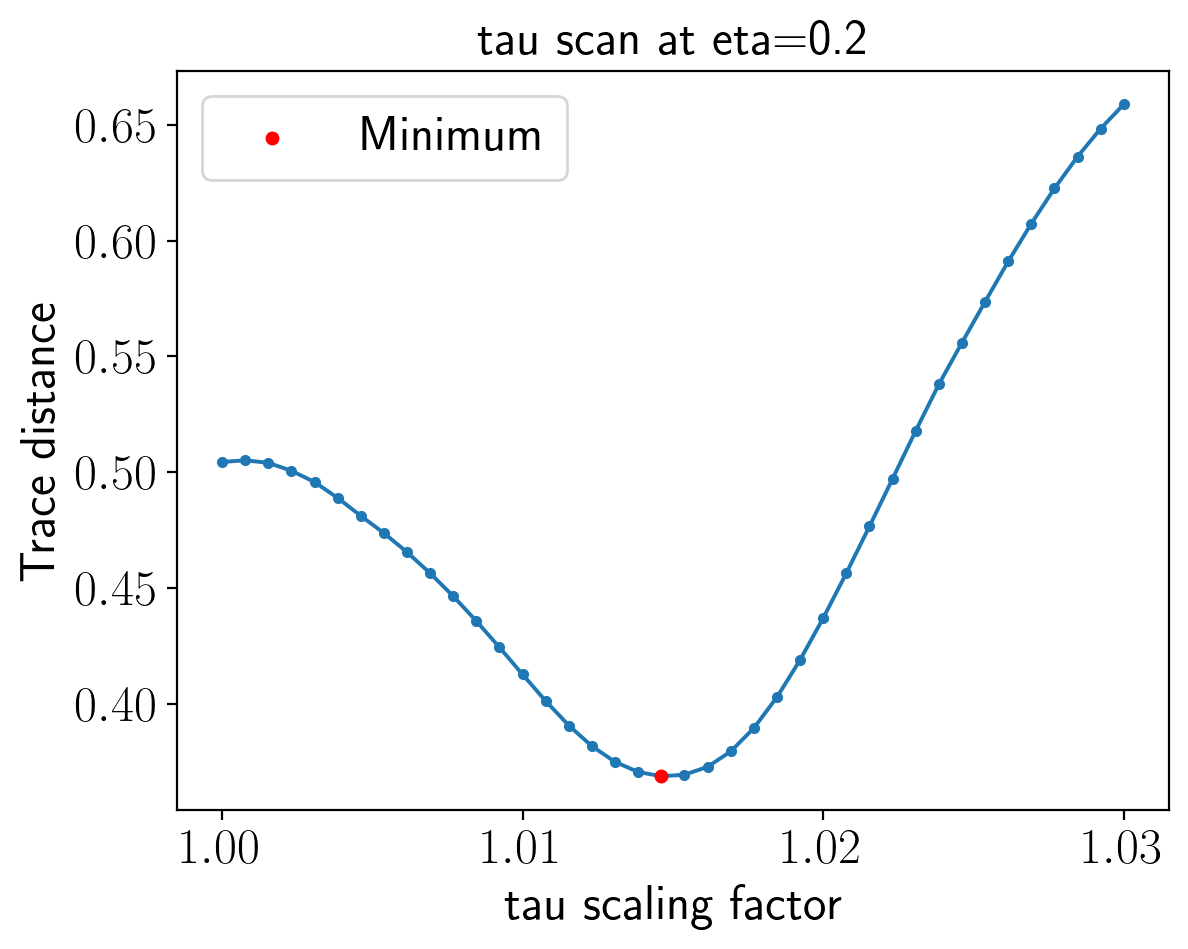

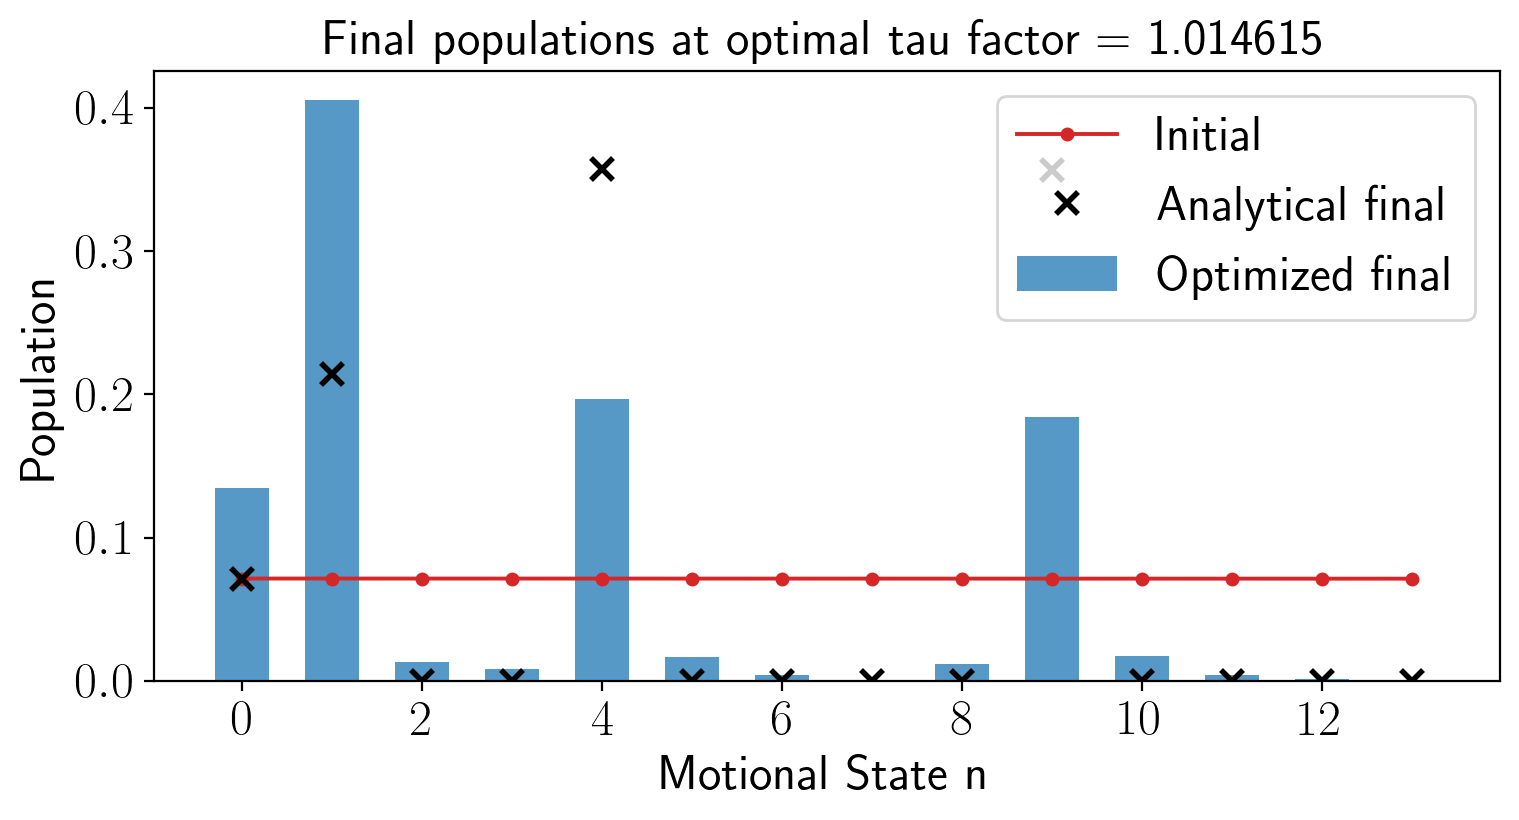

In [17]:
beta = 0.01    # Inverse temperature
# Initial state
thermal_state = (-beta * nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
initial_probs = np.real(np.array(thermal_state.diag())).flatten()


# Analytical final populations (trap-bin mapping)
expected_probs = np.zeros(N)
m = 0
while True:
    trap_idx = n0 * m**2
    next_trap_idx = n0 * (m + 1)**2

    # Stop if the trap state is beyond our truncation
    if trap_idx >= N:
        break

    # Define range for this trap bin: [trap_idx, next_trap_idx)
    start_n = trap_idx
    end_n = min(next_trap_idx, N)

    # Sum initial populations in this range
    if start_n < N:
        sum_p = np.sum(initial_probs[start_n:end_n])
        expected_probs[trap_idx] = sum_p

    m += 1

tau_factors = np.linspace(1, 1.03, 40)
trace_dists = []

# tracedist needs Qobj density matrices, not numpy arrays
expected_probs = np.clip(expected_probs, 0.0, None)
expected_probs = expected_probs / np.sum(expected_probs)
rho_expected = Qobj(np.diag(expected_probs), dims=[[N], [N]])

for f in tau_factors:
    tau_test = f * 2 * np.pi / (eta * Omega * np.sqrt(n0))
    L_x = liouvillian(H_x, [])
    prop_x_test = (L_x * tau_test).expm()
    prop_cycle_test = prop_diss * prop_rf_undo * prop_y_undo * prop_x_test * prop_y * prop_rf
    
    rho_vec = operator_to_vector(initial_state)
    for _ in range(num_pulses):
        rho_vec = prop_cycle_test * rho_vec
    
    rho_final = vector_to_operator(rho_vec).ptrace(1)
    trace_dists.append(float(tracedist(rho_final, rho_expected)))

trace_dists = np.array(trace_dists, dtype=float)
best_idx = int(np.argmin(trace_dists))
best_tau_factor = float(tau_factors[best_idx])
best_trace_dist = float(trace_dists[best_idx])

print(f'Best tau scaling factor: {best_tau_factor:.6f}')
print(f'Minimum trace distance: {best_trace_dist:.6e}')
if best_idx in (0, len(tau_factors) - 1):
    print('Minimum is at the scan boundary; widen tau_factors if you want a more reliable optimum.')

plt.figure()
plt.plot(tau_factors, trace_dists, marker='o', markersize=3)
plt.scatter([best_tau_factor], [best_trace_dist], color='red', zorder=3, label='Minimum')
plt.xlabel('tau scaling factor')
plt.ylabel('Trace distance')
plt.title(f'tau scan at eta={eta}')
plt.legend()
plt.show()

best_tau = best_tau_factor * 2 * np.pi / (eta * Omega * np.sqrt(n0))
prop_x_best = (L_x * best_tau).expm()
prop_cycle_best = prop_diss * prop_rf_undo * prop_y_undo * prop_x_best * prop_y * prop_rf

rho_vec_best = operator_to_vector(initial_state)
for _ in range(num_pulses):
    rho_vec_best = prop_cycle_best * rho_vec_best

rho_final_best = vector_to_operator(rho_vec_best).ptrace(1)
best_final_probs = np.real(np.array(rho_final_best.diag())).flatten()
best_final_probs = np.clip(best_final_probs, 0.0, None)
best_final_probs = best_final_probs / np.sum(best_final_probs)

n_vals = np.arange(N)
plt.figure(figsize=(8, 4.5))
plt.plot(n_vals, initial_probs, 'o-', color='tab:red', label='Initial')
plt.bar(n_vals, best_final_probs, width=0.6, alpha=0.75, label='Optimized final')
plt.plot(n_vals, expected_probs, 'x', markersize=8, markeredgewidth=2, color='k', label='Analytical final')
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title(f'Final populations at optimal tau factor = {best_tau_factor:.6f}')
plt.legend()
plt.tight_layout()
plt.show()